# Syllable DA Social vs Nonsocial

This notebook aligns subject-track Keypoint MoSeq syllables onto the DA table, then provides both:

- mean-DA heatmaps across syllables
- DA waveforms aligned to each syllable onset

for:

- `NAc`
- `mPFC`

across:

- `social`
- `nonsocial`
- social agent-role subsets (`agent_in_subject`, `subject_in_agent`, and `both` when present)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import friedmanchisquare, wilcoxon

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 120


## Paths And Settings

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in {"Pose_Tracking", "Keypoint_moseq_analysis"}:
    ROOT = PROJECT_ROOT.parent
else:
    ROOT = PROJECT_ROOT

POSE_DIR = ROOT / "Pose_Tracking"
KPMS_DIR = ROOT / "Keypoint_moseq_analysis"

MODEL_NAME = "2026_05_13-23_29_52"
USE_MERGED_SYLLABLES = True
TRACK_NAME = "subject"

PROJECT_DIR = KPMS_DIR / "keypoint_moseq_project_home_cage"
if not PROJECT_DIR.exists():
    PROJECT_DIR = POSE_DIR / "keypoint_moseq_project_home_cage"

MODEL_DIR = PROJECT_DIR / MODEL_NAME
SYLLABLE_PATH = MODEL_DIR / ("syllable_frames_merged.csv" if USE_MERGED_SYLLABLES else "syllable_frames.csv")
DA_PATH = POSE_DIR / "home_cage_pose_DA_all.csv"
OUTPUT_DIR = KPMS_DIR / "syllable_da_social_nonsocial"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_OUTPUTS = False

TIME_TOLERANCE_S = 0.11
TOP_N_SYLLABLES = 5
SYLLABLES_TO_EXCLUDE: list[int] = []
MIN_POINTS_PER_CELL = 15
MIN_EVENTS_PER_SYLLABLE = 8
REGION_ORDER = ["NAc", "mPFC"]
SOCIAL_ORDER = ["social", "nonsocial"]
SOCIAL_ROLE_ORDER = ["agent_in_subject", "subject_in_agent", "both"]
BOUT_PHASE_ORDER = ["Short_Term-1", "Short_Term-2", "Novel-1", "Long_Term-1"]
SHORT_TERM_1_MAX_S = 300
PETH_PRE_S = 2.0
PETH_POST_S = 3.0
PETH_DT_S = 0.1
PETH_NCOLS = 4
CMAP = "coolwarm"

PROJECT_DIR, MODEL_DIR, SYLLABLE_PATH, DA_PATH, OUTPUT_DIR


(WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage/2026_05_13-23_29_52'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/syllable_frames_merged.csv'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/home_cage_pose_DA_all.csv'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Keypoint_moseq_analysis/syllable_da_social_nonsocial'))

## Helper Functions

In [3]:
def infer_region_from_subject(subject_name: str) -> str:
    subject_name = str(subject_name).strip().lower()
    if subject_name.startswith("n"):
        return "NAc"
    if subject_name.startswith("p"):
        return "mPFC"
    return pd.NA


def classify_social_role(agent_in_subject, subject_in_agent):
    agent_yes = pd.Series(agent_in_subject).eq("Yes").to_numpy()
    subject_yes = pd.Series(subject_in_agent).eq("Yes").to_numpy()
    return np.select(
        [agent_yes & subject_yes, agent_yes, subject_yes],
        ["both", "agent_in_subject", "subject_in_agent"],
        default="none",
    )


def load_da_frame(da_path: Path) -> pd.DataFrame:
    usecols = [
        "time_s",
        "brain_region",
        "mouse_identity",
        "zscore_DA",
        "intruder_identity",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]
    df = pd.read_csv(da_path, usecols=usecols)
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
    df["zscore_DA"] = pd.to_numeric(df["zscore_DA"], errors="coerce")
    df = df.dropna(subset=["time_s", "zscore_DA"]).copy()

    df["subject_name"] = df["mouse_identity"].astype(str).str.strip()
    df["brain_region"] = df["brain_region"].astype(str).str.strip()
    df["bout_phase"] = df["intruder_identity"].astype(str).str.strip()
    df["social_proximity"] = df["agent_in_subject"].eq("Yes") | df["subject_in_agent"].eq("Yes")
    df["social_context"] = np.where(df["social_proximity"], "social", "nonsocial")
    df["social_role"] = classify_social_role(df["agent_in_subject"], df["subject_in_agent"])
    df = df.sort_values(["subject_name", "brain_region", "time_s"]).reset_index(drop=True)
    return df


def load_syllable_frame(syllable_path: Path, track_name: str) -> pd.DataFrame:
    usecols = [
        "recording_name",
        "frame_index",
        "syllable",
        "time_s",
        "subject_name",
        "track_name",
    ]
    df = pd.read_csv(syllable_path, usecols=usecols)
    df["time_s"] = pd.to_numeric(df["time_s"], errors="coerce")
    df["syllable"] = pd.to_numeric(df["syllable"], errors="coerce")
    df = df.dropna(subset=["time_s", "syllable"]).copy()
    df["syllable"] = df["syllable"].astype(int)
    df["subject_name"] = df["subject_name"].astype(str).str.strip()
    df = df[df["track_name"].astype(str).str.lower() == track_name.lower()].copy()
    df["brain_region"] = df["subject_name"].map(infer_region_from_subject)
    df = df.dropna(subset=["brain_region"]).copy()
    df = df.sort_values(["subject_name", "brain_region", "recording_name", "frame_index"]).reset_index(drop=True)
    return df


def merge_syllables_onto_da(
    da_df: pd.DataFrame,
    syllable_df: pd.DataFrame,
    *,
    tolerance_s: float,
) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    syllable_cols = ["time_s", "syllable", "recording_name", "frame_index"]

    for (subject_name, brain_region), da_rec in da_df.groupby(["subject_name", "brain_region"], sort=False):
        da_rec = da_rec.sort_values("time_s").reset_index(drop=True)
        syll_rec = syllable_df[
            (syllable_df["subject_name"] == subject_name)
            & (syllable_df["brain_region"] == brain_region)
        ][syllable_cols].sort_values("time_s").reset_index(drop=True)

        if syll_rec.empty:
            merged = da_rec.copy()
            merged["syllable"] = pd.NA
            merged["recording_name"] = pd.NA
            merged["frame_index"] = pd.NA
            parts.append(merged)
            continue

        merged = pd.merge_asof(
            da_rec,
            syll_rec,
            on="time_s",
            direction="nearest",
            tolerance=tolerance_s,
        )
        parts.append(merged)

    out = pd.concat(parts, ignore_index=True)
    out["syllable"] = pd.to_numeric(out["syllable"], errors="coerce")
    return out


def annotate_syllable_frames_with_da(
    syllable_df: pd.DataFrame,
    da_df: pd.DataFrame,
    *,
    tolerance_s: float,
) -> pd.DataFrame:
    parts: list[pd.DataFrame] = []
    da_cols = [
        "time_s",
        "zscore_DA",
        "bout_phase",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
        "social_proximity",
        "social_context",
        "social_role",
    ]

    for (subject_name, brain_region), syll_rec in syllable_df.groupby(["subject_name", "brain_region"], sort=False):
        syll_rec = syll_rec.sort_values("time_s").reset_index(drop=True)
        da_rec = da_df[
            (da_df["subject_name"] == subject_name)
            & (da_df["brain_region"] == brain_region)
        ][da_cols].sort_values("time_s").reset_index(drop=True)

        if da_rec.empty:
            merged = syll_rec.copy()
            merged["zscore_DA"] = np.nan
            merged["bout_phase"] = pd.NA
            merged["behavior_active"] = pd.NA
            merged["agent_in_subject"] = pd.NA
            merged["subject_in_agent"] = pd.NA
            merged["social_proximity"] = False
            merged["social_context"] = "nonsocial"
            merged["social_role"] = "none"
            parts.append(merged)
            continue

        merged = pd.merge_asof(
            syll_rec,
            da_rec,
            on="time_s",
            direction="nearest",
            tolerance=tolerance_s,
        )
        merged["social_proximity"] = merged["social_proximity"].fillna(False)
        merged["social_context"] = merged["social_context"].fillna("nonsocial")
        merged["social_role"] = merged["social_role"].fillna("none")
        parts.append(merged)

    return pd.concat(parts, ignore_index=True)


def exclude_syllables(df: pd.DataFrame, syllables_to_exclude: list[int] | None) -> pd.DataFrame:
    if not syllables_to_exclude:
        return df.copy()

    exclude_set = {int(syllable) for syllable in syllables_to_exclude}
    out = df.copy()
    out["syllable"] = pd.to_numeric(out["syllable"], errors="coerce")
    return out.loc[~out["syllable"].isin(exclude_set)].copy()


def summarize_mean_da_by_syllable(
    merged_df: pd.DataFrame,
    *,
    top_n_syllables: int,
    syllables_to_exclude: list[int] | None = None,
    min_points_per_cell: int,
) -> tuple[pd.DataFrame, list[int]]:
    valid = exclude_syllables(merged_df, syllables_to_exclude)
    valid = valid.dropna(subset=["syllable", "zscore_DA"]).copy()
    if valid.empty:
        return pd.DataFrame(), []

    valid["syllable"] = valid["syllable"].astype(int)

    top_syllables = (
        valid.groupby("syllable", observed=True)
        .size()
        .sort_values(ascending=False)
        .head(top_n_syllables)
        .index
        .tolist()
    )
    valid = valid[valid["syllable"].isin(top_syllables)].copy()

    summary = (
        valid.groupby(["brain_region", "social_context", "syllable"], as_index=False, observed=True)
        .agg(
            n=("zscore_DA", "size"),
            mean_DA=("zscore_DA", "mean"),
            median_DA=("zscore_DA", "median"),
            std_DA=("zscore_DA", "std"),
            n_subjects=("subject_name", "nunique"),
        )
    )
    summary["sem_DA"] = summary["std_DA"] / np.sqrt(summary["n"].clip(lower=1))
    summary["meets_min_points"] = summary["n"] >= min_points_per_cell
    summary.loc[~summary["meets_min_points"], "mean_DA"] = np.nan

    return summary.sort_values(["brain_region", "social_context", "syllable"]).reset_index(drop=True), top_syllables


def filter_bout_windows(df: pd.DataFrame, short_term_1_max_s: float) -> pd.DataFrame:
    out = df.copy()
    out["bout_elapsed_s"] = out.groupby(["subject_name", "brain_region", "bout_phase"], sort=False)["time_s"].transform(
        lambda s: s - s.min()
    )
    keep_mask = ~out["bout_phase"].eq("Short_Term-1") | out["bout_elapsed_s"].le(short_term_1_max_s)
    return out.loc[keep_mask].copy()



def summarize_mean_da_by_syllable_and_bout(
    merged_df: pd.DataFrame,
    *,
    syllable_order: list[int],
    min_points_per_cell: int,
) -> pd.DataFrame:
    valid = merged_df.dropna(subset=["syllable", "zscore_DA", "bout_phase"]).copy()
    if valid.empty:
        return pd.DataFrame()

    valid["syllable"] = valid["syllable"].astype(int)
    valid = valid[valid["syllable"].isin(syllable_order)].copy()

    summary = (
        valid.groupby(["brain_region", "bout_phase", "social_context", "syllable"], as_index=False, observed=True)
        .agg(
            n=("zscore_DA", "size"),
            mean_DA=("zscore_DA", "mean"),
            median_DA=("zscore_DA", "median"),
            std_DA=("zscore_DA", "std"),
            n_subjects=("subject_name", "nunique"),
        )
    )
    summary["sem_DA"] = summary["std_DA"] / np.sqrt(summary["n"].clip(lower=1))
    summary["meets_min_points"] = summary["n"] >= min_points_per_cell
    summary.loc[~summary["meets_min_points"], "mean_DA"] = np.nan
    return summary.sort_values(["brain_region", "bout_phase", "social_context", "syllable"]).reset_index(drop=True)


def plot_region_heatmap(
    summary_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    social_context: str | None = None,
    output_path: Path | None = None,
) -> None:
    region_df = summary_df[summary_df["brain_region"].eq(region)].copy()
    if social_context is not None:
        region_df = region_df[region_df["social_context"].eq(social_context)].copy()
    if region_df.empty:
        return

    row_order = SOCIAL_ORDER if social_context is None else [social_context]

    heatmap_df = (
        region_df.pivot(index="social_context", columns="syllable", values="mean_DA")
        .reindex(index=row_order)
        .reindex(columns=syllable_order)
    )
    annot_df = (
        region_df.pivot(index="social_context", columns="syllable", values="n")
        .reindex(index=row_order)
        .reindex(columns=syllable_order)
    )

    if heatmap_df.notna().sum().sum() == 0:
        return

    finite_values = heatmap_df.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(finite_values))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    fig_height = 3.8 if social_context is None else 2.6
    plt.figure(figsize=(max(12, 0.55 * len(syllable_order)), fig_height))
    ax = sns.heatmap(
        heatmap_df,
        cmap=CMAP,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean z-scored DA"},
    )
    context_label = "social + nonsocial" if social_context is None else social_context
    ax.set_title(f"{region} mean DA by syllable ({context_label})")
    ax.set_xlabel("Syllable")
    ax.set_ylabel("Context")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()


def plot_region_barplot(
    summary_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    social_context: str | None = None,
    output_path: Path | None = None,
) -> None:
    region_df = summary_df[summary_df["brain_region"].eq(region)].copy()
    if social_context is not None:
        region_df = region_df[region_df["social_context"].eq(social_context)].copy()
    region_df = region_df.dropna(subset=["mean_DA"]).copy()
    if region_df.empty:
        return

    context_order = SOCIAL_ORDER if social_context is None else [social_context]
    plot_df = region_df.copy()
    plot_df["syllable"] = pd.Categorical(plot_df["syllable"], categories=syllable_order, ordered=True)
    plot_df = plot_df.sort_values(["syllable", "social_context"]).reset_index(drop=True)

    plt.figure(figsize=(max(12, 0.6 * len(syllable_order)), 4.5))
    ax = sns.barplot(
        data=plot_df,
        x="syllable",
        y="mean_DA",
        hue="social_context",
        order=syllable_order,
        hue_order=context_order,
        errorbar=None,
        dodge=True,
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.7)

    for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        sem = row.get("sem_DA", np.nan)
        if pd.notna(sem):
            ax.errorbar(x, y, yerr=sem, color="black", capsize=2, linewidth=1)
        if pd.notna(y):
            offset = 0.03 if y >= 0 else -0.05
            va = "bottom" if y >= 0 else "top"
            ax.text(x, y + offset, f"n={int(row['n'])}", ha="center", va=va, fontsize=8, rotation=90)
    context_label = "social + nonsocial" if social_context is None else social_context
    ax.set_title(f"{region} mean DA by syllable ({context_label}, bar plot)")
    ax.set_xlabel("Syllable")
    ax.set_ylabel("Mean z-scored DA")
    plt.xticks(rotation=45, ha="right")
    if social_context is None:
        ax.legend(title="Context", frameon=False)
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()


def plot_region_agent_comparison_heatmap(
    summary_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    social_context: str | None = None,
    output_path: Path | None = None,
) -> None:
    region_df = summary_df[summary_df["brain_region"].eq(region)].copy()
    if social_context is not None:
        region_df = region_df[region_df["social_context"].eq(social_context)].copy()
    if region_df.empty:
        return

    if social_context is None:
        region_df["row_label"] = region_df["bout_phase"].astype(str) + " | " + region_df["social_context"].astype(str)
        row_key = "row_label"
        row_order = [f"{bout} | {context}" for bout in BOUT_PHASE_ORDER for context in SOCIAL_ORDER]
        ylabel = "Bout phase | context"
        title_context = "social + nonsocial"
        fig_height = 3.8
    else:
        row_key = "bout_phase"
        row_order = BOUT_PHASE_ORDER
        ylabel = "Bout phase"
        title_context = social_context
        fig_height = 3.2

    heatmap_df = (
        region_df.pivot(index=row_key, columns="syllable", values="mean_DA")
        .reindex(index=row_order)
        .reindex(columns=syllable_order)
    )
    annot_df = (
        region_df.pivot(index=row_key, columns="syllable", values="n")
        .reindex(index=row_order)
        .reindex(columns=syllable_order)
    )

    if heatmap_df.notna().sum().sum() == 0:
        return

    finite_values = heatmap_df.to_numpy(dtype=float)
    vmax = np.nanmax(np.abs(finite_values))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1.0

    plt.figure(figsize=(max(12, 0.55 * len(syllable_order)), fig_height))
    ax = sns.heatmap(
        heatmap_df,
        cmap=CMAP,
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Mean z-scored DA"},
    )
    ax.set_title(f"{region} mean DA by syllable across bouts ({title_context})")
    ax.set_xlabel("Syllable")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()


def plot_region_agent_comparison_barplot(
    summary_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    social_context: str | None = None,
    pairwise_stats_df: pd.DataFrame | None = None,
    output_path: Path | None = None,
) -> None:
    region_df = summary_df[summary_df["brain_region"].eq(region)].copy()
    if social_context is not None:
        region_df = region_df[region_df["social_context"].eq(social_context)].copy()
    region_df = region_df.dropna(subset=["mean_DA"]).copy()
    if region_df.empty:
        return

    if social_context is None:
        region_df["group_label"] = region_df["bout_phase"].astype(str) + " | " + region_df["social_context"].astype(str)
        hue_key = "group_label"
        hue_order = [f"{bout} | {context}" for bout in BOUT_PHASE_ORDER for context in SOCIAL_ORDER]
        title_context = "social + nonsocial"
    else:
        hue_key = "bout_phase"
        hue_order = BOUT_PHASE_ORDER
        title_context = social_context

    plot_df = region_df.copy()
    plot_df["syllable"] = pd.Categorical(plot_df["syllable"], categories=syllable_order, ordered=True)
    plot_df = plot_df.sort_values(["syllable", hue_key]).reset_index(drop=True)

    plt.figure(figsize=(max(14, 0.7 * len(syllable_order)), 5))
    ax = sns.barplot(
        data=plot_df,
        x="syllable",
        y="mean_DA",
        hue=hue_key,
        order=syllable_order,
        hue_order=hue_order,
        errorbar=None,
        dodge=True,
    )
    ax.axhline(0, color="black", linewidth=1, alpha=0.7)

    for patch, (_, row) in zip(ax.patches, plot_df.iterrows()):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        sem = row.get("sem_DA", np.nan)
        if pd.notna(sem):
            ax.errorbar(x, y, yerr=sem, color="black", capsize=2, linewidth=1)
    ax.set_title(f"{region} mean DA by syllable across bouts ({title_context}, bar plot)")
    ax.set_xlabel("Syllable")
    ax.set_ylabel("Mean z-scored DA")

    if social_context == "social" and pairwise_stats_df is not None and not pairwise_stats_df.empty:
        stats_region = pairwise_stats_df[pairwise_stats_df["brain_region"].eq(region)].copy()
        if not stats_region.empty:
            abbr_map = {
                "Short_Term-1": "ST1",
                "Short_Term-2": "ST2",
                "Novel-1": "NOV",
                "Long_Term-1": "LT",
            }
            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min if y_max > y_min else 1.0
            x_lookup = {syll: idx for idx, syll in enumerate(syllable_order)}
            for syllable in syllable_order:
                syll_stats = stats_region[
                    stats_region["syllable"].eq(syllable) & stats_region["p_value_fdr_bh"].lt(0.05)
                ].copy()
                if syll_stats.empty:
                    continue
                syll_plot = plot_df[plot_df["syllable"].eq(syllable)].copy()
                if syll_plot.empty:
                    continue
                labels = []
                for _, stat_row in syll_stats.iterrows():
                    a = abbr_map.get(stat_row["agent_a"], str(stat_row["agent_a"]))
                    b = abbr_map.get(stat_row["agent_b"], str(stat_row["agent_b"]))
                    labels.append(f"{a} vs {b}*")
                y_star = float(syll_plot["mean_DA"].max()) + 0.08 * y_range
                ax.text(
                    x_lookup[syllable],
                    y_star,
                    "\n".join(labels),
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )
            ax.set_ylim(y_min, y_max + 0.24 * y_range)
    plt.xticks(rotation=45, ha="right")
    ax.legend(title="Bout / context" if social_context is None else "Bout phase", frameon=False)
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()
def extract_syllable_onset_events(syllable_df: pd.DataFrame, *, syllable_order: list[int]) -> pd.DataFrame:
    rows: list[pd.DataFrame] = []

    for recording_name, rec in syllable_df.groupby("recording_name", sort=False):
        rec = rec.sort_values("frame_index").reset_index(drop=True)
        if rec.empty:
            continue

        frame_gap = rec["frame_index"].diff().fillna(1)
        syllable_change = rec["syllable"].ne(rec["syllable"].shift())
        onset_mask = syllable_change | frame_gap.ne(1)
        onset_rec = rec.loc[onset_mask].copy()
        onset_rec = onset_rec[onset_rec["syllable"].isin(syllable_order)].copy()
        if onset_rec.empty:
            continue

        onset_rec = onset_rec.rename(
            columns={
                "time_s": "onset_time_s",
                "frame_index": "onset_frame_index",
            }
        )
        rows.append(onset_rec)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.reset_index(drop=True)
    out.insert(0, "event_id", np.arange(len(out)))
    return out


def build_syllable_onset_peth(
    onset_df: pd.DataFrame,
    da_df: pd.DataFrame,
    *,
    pre_s: float,
    post_s: float,
    dt_s: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if onset_df.empty:
        empty_events = pd.DataFrame(columns=["event_id", "subject_name", "brain_region", "recording_name", "syllable", "social_context", "social_role"])
        empty_long = pd.DataFrame(columns=["event_id", "subject_name", "brain_region", "recording_name", "syllable", "bout_phase", "social_context", "social_role", "rel_time_s", "zscore_DA"])
        return empty_events, empty_long

    rel_grid = np.arange(-pre_s, post_s + dt_s / 2, dt_s)
    aligned_events = []
    aligned_rows = []

    for (subject_name, brain_region), events in onset_df.groupby(["subject_name", "brain_region"], sort=False):
        da_rec = da_df[
            (da_df["subject_name"] == subject_name)
            & (da_df["brain_region"] == brain_region)
        ].sort_values("time_s").reset_index(drop=True)
        if da_rec.empty:
            continue

        min_time = float(da_rec["time_s"].min())
        max_time = float(da_rec["time_s"].max())

        for _, event in events.iterrows():
            onset_time = float(event["onset_time_s"])
            if onset_time - pre_s < min_time or onset_time + post_s > max_time:
                continue

            seg = da_rec[da_rec["time_s"].between(onset_time - pre_s, onset_time + post_s, inclusive="both")].copy()
            if len(seg) < 2:
                continue

            rel_time = seg["time_s"].to_numpy(dtype=float) - onset_time
            trace = np.interp(rel_grid, rel_time, seg["zscore_DA"].to_numpy(dtype=float))
            event_record = event.to_dict()
            event_record["trace"] = trace.tolist()
            aligned_events.append(event_record)

            for rel_t, z_da in zip(rel_grid, trace):
                aligned_rows.append(
                    {
                        "event_id": event_record["event_id"],
                        "subject_name": subject_name,
                        "brain_region": brain_region,
                        "recording_name": event_record["recording_name"],
                        "syllable": event_record["syllable"],
                        "bout_phase": event_record.get("bout_phase", pd.NA),
                        "social_context": event_record.get("social_context", "nonsocial"),
                        "social_role": event_record.get("social_role", "none"),
                        "rel_time_s": float(rel_t),
                        "zscore_DA": float(z_da),
                    }
                )

    return pd.DataFrame(aligned_events), pd.DataFrame(aligned_rows)


def summarize_onset_counts(events_df: pd.DataFrame) -> pd.DataFrame:
    if events_df.empty:
        return pd.DataFrame(columns=["brain_region", "social_context", "social_role", "syllable", "n_events", "n_subjects"])

    return (
        events_df.groupby(["brain_region", "social_context", "social_role", "syllable"], as_index=False, observed=True)
        .agg(
            n_events=("event_id", "nunique"),
            n_subjects=("subject_name", "nunique"),
        )
        .sort_values(["brain_region", "social_context", "social_role", "syllable"])
        .reset_index(drop=True)
    )


def _compute_trace_stats(plot_df: pd.DataFrame) -> pd.DataFrame:
    if plot_df.empty:
        return pd.DataFrame(columns=["rel_time_s", "mean", "sem", "n_events"])

    stats = (
        plot_df.groupby("rel_time_s", as_index=False)
        .agg(
            mean=("zscore_DA", "mean"),
            sem=("zscore_DA", lambda x: x.std(ddof=1) / np.sqrt(max(len(x), 1))),
            n_events=("event_id", "nunique"),
        )
        .sort_values("rel_time_s")
        .reset_index(drop=True)
    )
    stats["sem"] = stats["sem"].fillna(0.0)
    return stats


def plot_syllable_onset_peth_grid(
    long_df: pd.DataFrame,
    events_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    social_context: str | None = None,
    social_role: str | None = None,
    min_events_per_syllable: int,
    ncols: int,
) -> None:
    plot_events = events_df[events_df["brain_region"].eq(region)].copy()
    plot_long = long_df[long_df["brain_region"].eq(region)].copy()

    if social_context is not None:
        plot_events = plot_events[plot_events["social_context"].eq(social_context)].copy()
        plot_long = plot_long[plot_long["social_context"].eq(social_context)].copy()
    if social_role is not None:
        plot_events = plot_events[plot_events["social_role"].eq(social_role)].copy()
        plot_long = plot_long[plot_long["social_role"].eq(social_role)].copy()

    if plot_events.empty or plot_long.empty:
        print(f"No syllable onsets available for {region}, social_context={social_context}, social_role={social_role}")
        return

    counts = plot_events.groupby("syllable", observed=True)["event_id"].nunique()
    syllables_to_plot = [
        syllable for syllable in syllable_order
        if counts.get(syllable, 0) >= min_events_per_syllable
    ]
    if not syllables_to_plot:
        print(f"No syllables met the minimum event threshold for {region}, social_context={social_context}, social_role={social_role}")
        return

    nplots = len(syllables_to_plot)
    nrows = int(np.ceil(nplots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, syllable in zip(axes, syllables_to_plot):
        syllable_long = plot_long[plot_long["syllable"].eq(syllable)].copy()
        syllable_events = plot_events[plot_events["syllable"].eq(syllable)].copy()
        stats = _compute_trace_stats(syllable_long)

        ax.plot(stats["rel_time_s"], stats["mean"], color="#1f77b4", linewidth=2)
        ax.fill_between(
            stats["rel_time_s"],
            stats["mean"] - stats["sem"],
            stats["mean"] + stats["sem"],
            color="#1f77b4",
            alpha=0.2,
        )
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.axhline(0, color="0.7", linestyle=":", linewidth=1)
        ax.set_title(f"Syllable {syllable} | n={syllable_events['event_id'].nunique()}")
        ax.set_xlabel("Time from onset (s)")
        ax.set_ylabel("z-scored DA")

    for ax in axes[nplots:]:
        ax.axis("off")

    context_label = social_context if social_context is not None else "all contexts"
    role_label = social_role if social_role is not None else "all roles"
    fig.suptitle(f"{region} syllable-onset DA waveforms | {context_label} | {role_label}", y=1.02)
    fig.tight_layout()
    plt.show()




## Load And Merge Data

In [4]:
da_df = load_da_frame(DA_PATH)
syllable_df = load_syllable_frame(SYLLABLE_PATH, TRACK_NAME)
merged_df = merge_syllables_onto_da(da_df, syllable_df, tolerance_s=TIME_TOLERANCE_S)
merged_df = filter_bout_windows(merged_df, SHORT_TERM_1_MAX_S)

display(merged_df.head())
print(merged_df[["subject_name", "brain_region", "social_context", "syllable"]].dropna().shape)


,time_s,brain_region,mouse_identity,zscore_DA,intruder_identity,agent_in_subject,subject_in_agent,behavior_active,subject_name,bout_phase,social_proximity,social_context,social_role,syllable,recording_name,frame_index,bout_elapsed_s
0,184.1,NAc,n5,-0.518274,Short_Term-1,No,No,NaN,n5,Short_Term-1,False,nonsocial,none,4.0,n5_subject,1841.0,0.0
1,184.2,NAc,n5,-0.327248,Short_Term-1,No,No,NaN,n5,Short_Term-1,False,nonsocial,none,4.0,n5_subject,1842.0,0.1
2,184.3,NAc,n5,-0.295615,Short_Term-1,No,No,NaN,n5,Short_Term-1,False,nonsocial,none,4.0,n5_subject,1843.0,0.2
3,184.4,NAc,n5,-0.349986,Short_Term-1,No,No,NaN,n5,Short_Term-1,False,nonsocial,none,4.0,n5_subject,1844.0,0.3
4,184.5,NAc,n5,-0.483705,Short_Term-1,No,No,NaN,n5,Short_Term-1,False,nonsocial,none,4.0,n5_subject,1845.0,0.4


(233321, 4)


## Summarize Mean DA By Syllable


In [5]:

def benjamini_hochberg(p_values: list[float]) -> list[float]:
    if not p_values:
        return []

    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = np.empty(n, dtype=float)

    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        value = min(prev, ranked[i] * n / rank)
        adjusted[i] = value
        prev = value

    result = np.empty(n, dtype=float)
    result[order] = np.clip(adjusted, 0.0, 1.0)
    return result.tolist()


def safe_wilcoxon(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    diff = x.to_numpy(dtype=float) - y.to_numpy(dtype=float)
    if np.allclose(diff, 0.0, equal_nan=False):
        return 0.0, 1.0
    stat, p_value = wilcoxon(x, y, zero_method='wilcox', alternative='two-sided', method='auto')
    return float(stat), float(p_value)


def build_subject_level_syllable_da(frame_df: pd.DataFrame, syllable_order: list[int]) -> pd.DataFrame:
    valid = frame_df.dropna(
        subset=['brain_region', 'subject_name', 'intruder_identity', 'social_context', 'syllable', 'zscore_DA']
    ).copy()
    valid['syllable'] = valid['syllable'].astype(int)
    valid = valid[valid['syllable'].isin(syllable_order)].copy()

    return (
        valid.groupby(
            ['brain_region', 'subject_name', 'intruder_identity', 'social_context', 'syllable'],
            as_index=False,
            observed=True,
        )
        .agg(mean_DA=('zscore_DA', 'mean'), n_frames=('zscore_DA', 'size'))
        .sort_values(['brain_region', 'subject_name', 'intruder_identity', 'social_context', 'syllable'])
        .reset_index(drop=True)
    )



def run_top_syllable_stats(subject_level_df: pd.DataFrame, min_paired_subjects: int = 3):
    agent_collapsed = (
        subject_level_df.groupby(
            ['brain_region', 'subject_name', 'intruder_identity', 'syllable'],
            as_index=False,
            observed=True,
        )
        .agg(mean_DA=('mean_DA', 'mean'))
    )

    omnibus_rows = []
    pairwise_rows = []
    for (brain_region, syllable), group in agent_collapsed.groupby(['brain_region', 'syllable'], observed=True):
        wide = group.pivot(index='subject_name', columns='intruder_identity', values='mean_DA')
        wide = wide.sort_index(axis=1)
        complete = wide.dropna()
        agent_levels = complete.columns.tolist()
        row = {
            'brain_region': brain_region,
            'syllable': int(syllable),
            'agent_levels': '|'.join(agent_levels),
            'n_agents': len(agent_levels),
            'n_subjects_complete': int(complete.shape[0]),
            'test': 'Friedman',
        }
        if complete.shape[0] >= min_paired_subjects and complete.shape[1] >= 3:
            stat, p_value = friedmanchisquare(*[complete[col].to_numpy() for col in complete.columns])
            row['statistic'] = float(stat)
            row['p_value'] = float(p_value)
            row['kendalls_w'] = float(stat) / (complete.shape[0] * (complete.shape[1] - 1))
        else:
            row['statistic'] = np.nan
            row['p_value'] = np.nan
            row['kendalls_w'] = np.nan
        omnibus_rows.append(row)

        block_indices = []
        block_p = []
        for agent_a, agent_b in __import__('itertools').combinations(wide.columns.tolist(), 2):
            paired = wide[[agent_a, agent_b]].dropna()
            pair_row = {
                'brain_region': brain_region,
                'syllable': int(syllable),
                'agent_a': agent_a,
                'agent_b': agent_b,
                'n_subjects_paired': int(paired.shape[0]),
                'test': 'Wilcoxon signed-rank',
            }
            if paired.shape[0] >= min_paired_subjects:
                stat, p_value = safe_wilcoxon(paired[agent_a], paired[agent_b])
                diffs = paired[agent_a] - paired[agent_b]
                pair_row['statistic'] = stat
                pair_row['p_value'] = p_value
                pair_row['mean_diff_a_minus_b'] = float(diffs.mean())
                pair_row['median_diff_a_minus_b'] = float(diffs.median())
                block_indices.append(len(pairwise_rows))
                block_p.append(p_value)
            else:
                pair_row['statistic'] = np.nan
                pair_row['p_value'] = np.nan
                pair_row['mean_diff_a_minus_b'] = np.nan
                pair_row['median_diff_a_minus_b'] = np.nan
            pairwise_rows.append(pair_row)

        adj = benjamini_hochberg(block_p)
        for idx, adj_p in zip(block_indices, adj):
            pairwise_rows[idx]['p_value_fdr_bh'] = adj_p

    agent_omnibus_df = pd.DataFrame(omnibus_rows)
    agent_pairwise_df = pd.DataFrame(pairwise_rows)
    if 'p_value_fdr_bh' not in agent_pairwise_df.columns:
        agent_pairwise_df['p_value_fdr_bh'] = np.nan
    agent_pairwise_df['p_value_fdr_bh'] = agent_pairwise_df['p_value_fdr_bh'].astype(float)

    social_collapsed = (
        subject_level_df.groupby(
            ['brain_region', 'subject_name', 'social_context', 'syllable'],
            as_index=False,
            observed=True,
        )
        .agg(mean_DA=('mean_DA', 'mean'))
    )

    social_rows = []
    for (brain_region, syllable), group in social_collapsed.groupby(['brain_region', 'syllable'], observed=True):
        wide = group.pivot(index='subject_name', columns='social_context', values='mean_DA')
        paired = wide[['social', 'nonsocial']].dropna() if {'social', 'nonsocial'}.issubset(wide.columns) else pd.DataFrame()
        row = {
            'brain_region': brain_region,
            'syllable': int(syllable),
            'n_subjects_paired': int(paired.shape[0]),
            'test': 'Wilcoxon signed-rank',
        }
        if paired.shape[0] >= min_paired_subjects:
            stat, p_value = safe_wilcoxon(paired['social'], paired['nonsocial'])
            diffs = paired['social'] - paired['nonsocial']
            row['statistic'] = stat
            row['p_value'] = p_value
            row['mean_social'] = float(paired['social'].mean())
            row['mean_nonsocial'] = float(paired['nonsocial'].mean())
            row['mean_diff_social_minus_nonsocial'] = float(diffs.mean())
            row['median_diff_social_minus_nonsocial'] = float(diffs.median())
        else:
            row['statistic'] = np.nan
            row['p_value'] = np.nan
            row['mean_social'] = np.nan
            row['mean_nonsocial'] = np.nan
            row['mean_diff_social_minus_nonsocial'] = np.nan
            row['median_diff_social_minus_nonsocial'] = np.nan
        social_rows.append(row)

    social_stats_df = pd.DataFrame(social_rows).sort_values(['brain_region', 'syllable']).reset_index(drop=True)
    valid_mask = social_stats_df['p_value'].notna()
    social_stats_df.loc[valid_mask, 'p_value_fdr_bh'] = benjamini_hochberg(social_stats_df.loc[valid_mask, 'p_value'].tolist())
    social_stats_df.loc[~valid_mask, 'p_value_fdr_bh'] = np.nan

    return agent_omnibus_df, agent_pairwise_df, social_stats_df
def p_to_stars(p_value) -> str:
    if pd.isna(p_value):
        return ''
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    return ''


def plot_social_context_significance_heatmap(
    social_stats_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    fdr_column: str = 'p_value_fdr_bh',
    output_path: Path | None = None,
) -> None:
    region_df = social_stats_df[social_stats_df['brain_region'].eq(region)].copy()
    if region_df.empty:
        print(f'No social-context stats available for {region}.')
        return

    mean_diff_by_syllable = (
        region_df.groupby('syllable', as_index=True)['mean_diff_social_minus_nonsocial']
        .mean()
        .reindex(syllable_order)
    )
    effect_df = pd.DataFrame(
        [mean_diff_by_syllable.to_numpy()],
        index=['social - nonsocial'],
        columns=syllable_order,
    )

    finite_values = effect_df.to_numpy(dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    vmax = np.nanmax(np.abs(finite_values)) if finite_values.size else 1.0
    vmax = max(vmax, 0.05)

    plt.figure(figsize=(0.85 * max(len(syllable_order), 6), 2.7))
    ax = sns.heatmap(
        effect_df,
        cmap='coolwarm',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Mean DA difference (social - nonsocial)'},
    )
    ax.set_title(f'{region} mean DA difference (social - nonsocial) by syllable')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('Comparison')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()



def plot_agent_pairwise_significance_heatmap(
    agent_pairwise_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    fdr_column: str = 'p_value_fdr_bh',
    output_path: Path | None = None,
) -> None:
    region_df = agent_pairwise_df[agent_pairwise_df['brain_region'].eq(region)].copy()
    if region_df.empty:
        print(f'No agent pairwise stats available for {region}.')
        return

    region_df['pair_label'] = region_df['agent_a'].astype(str) + ' vs ' + region_df['agent_b'].astype(str)
    effect_df = (
        region_df.pivot(index='pair_label', columns='syllable', values='mean_diff_a_minus_b')
        .reindex(columns=syllable_order)
    )
    star_df = (
        region_df.assign(stars=region_df[fdr_column].map(p_to_stars))
        .pivot(index='pair_label', columns='syllable', values='stars')
        .reindex(index=effect_df.index, columns=effect_df.columns)
        .fillna('')
    )

    finite_values = effect_df.to_numpy(dtype=float)
    finite_values = finite_values[np.isfinite(finite_values)]
    vmax = np.nanmax(np.abs(finite_values)) if finite_values.size else 1.0
    vmax = max(vmax, 0.05)

    plt.figure(figsize=(0.85 * max(len(syllable_order), 6), 0.55 * max(len(effect_df.index), 4) + 1.5))
    ax = sns.heatmap(
        effect_df,
        cmap='coolwarm',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        linewidths=0.5,
        linecolor='white',
        annot=star_df,
        fmt='',
        cbar_kws={'label': 'Mean DA difference (agent_a - agent_b)'},
    )
    ax.set_title(f'{region} agent pairwise significance by syllable')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('Agent comparison')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()



def plot_social_context_barplot(
    subject_level_df: pd.DataFrame,
    social_stats_df: pd.DataFrame,
    *,
    region: str,
    syllable_order: list[int],
    fdr_column: str = 'p_value_fdr_bh',
    output_path: Path | None = None,
) -> None:
    region_subject_df = subject_level_df[subject_level_df['brain_region'].eq(region)].copy()
    if region_subject_df.empty:
        print(f'No subject-level data available for {region}.')
        return

    plot_df = (
        region_subject_df.groupby(
            ['brain_region', 'subject_name', 'social_context', 'syllable'],
            as_index=False,
            observed=True,
        )
        .agg(mean_DA=('mean_DA', 'mean'))
    )
    plot_df = plot_df[plot_df['syllable'].isin(syllable_order)].copy()
    plot_df['syllable'] = pd.Categorical(plot_df['syllable'], categories=syllable_order, ordered=True)
    plot_df['social_context'] = pd.Categorical(plot_df['social_context'], categories=SOCIAL_ORDER, ordered=True)

    palette = {'social': '#d95f02', 'nonsocial': '#1b9e77'}

    fig, ax = plt.subplots(figsize=(max(10, 0.95 * len(syllable_order)), 5.2))
    sns.barplot(
        data=plot_df,
        x='syllable',
        y='mean_DA',
        hue='social_context',
        order=syllable_order,
        hue_order=SOCIAL_ORDER,
        estimator=np.mean,
        errorbar='se',
        palette=palette,
        ax=ax,
    )

    subject_pivot = (
        plot_df.pivot_table(
            index=['subject_name', 'syllable'],
            columns='social_context',
            values='mean_DA',
            aggfunc='mean',
            observed=True,
        )
        .reset_index()
    )
    x_lookup = {syll: idx for idx, syll in enumerate(syllable_order)}
    left_offset = -0.2
    right_offset = 0.2
    for _, row in subject_pivot.iterrows():
        if pd.isna(row.get('social')) or pd.isna(row.get('nonsocial')):
            continue
        syllable = int(row['syllable'])
        x_center = x_lookup[syllable]
        ax.plot(
            [x_center + left_offset, x_center + right_offset],
            [row['social'], row['nonsocial']],
            color='0.55',
            alpha=0.35,
            linewidth=0.8,
            zorder=1,
        )
        ax.scatter(x_center + left_offset, row['social'], color='black', alpha=0.45, s=14, zorder=2)
        ax.scatter(x_center + right_offset, row['nonsocial'], color='black', alpha=0.45, s=14, zorder=2)

    stats_region = social_stats_df[social_stats_df['brain_region'].eq(region)].copy()
    if not stats_region.empty:
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min if y_max > y_min else 1.0
        for syllable in syllable_order:
            stat_row = stats_region[stats_region['syllable'].eq(syllable)]
            if stat_row.empty:
                continue
            star = p_to_stars(stat_row[fdr_column].iloc[0])
            if not star:
                continue
            syllable_points = plot_df[plot_df['syllable'].eq(syllable)]['mean_DA']
            if syllable_points.empty:
                continue
            y_star = float(syllable_points.max()) + 0.08 * y_range
            ax.text(x_lookup[syllable], y_star, star, ha='center', va='bottom', fontsize=11, fontweight='bold')
        ax.set_ylim(y_min, y_max + 0.18 * y_range)

    ax.axhline(0, color='0.3', linewidth=0.8, linestyle='--')
    ax.set_title(f'{region} social vs nonsocial by syllable')
    ax.set_xlabel('Syllable')
    ax.set_ylabel('Mean z-scored DA')
    ax.legend(title='Context', frameon=False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200)
    plt.show()


In [6]:
summary_df, top_syllables = summarize_mean_da_by_syllable(
    merged_df,
    top_n_syllables=TOP_N_SYLLABLES,
    syllables_to_exclude=SYLLABLES_TO_EXCLUDE,
    min_points_per_cell=MIN_POINTS_PER_CELL,
)

display(summary_df.head(20))
print("Excluded syllables:", SYLLABLES_TO_EXCLUDE)
print("Top syllables:", top_syllables)


,brain_region,social_context,syllable,n,mean_DA,median_DA,std_DA,n_subjects,sem_DA,meets_min_points
0,NAc,nonsocial,1,4523,0.011129,-0.145626,0.930816,11,0.013840,True
1,NAc,nonsocial,4,7668,-0.099335,-0.237969,0.829996,11,0.009478,True
2,NAc,nonsocial,5,18397,-0.021437,-0.224907,0.986373,11,0.007272,True
3,NAc,nonsocial,9,6836,0.095862,-0.168516,1.125486,11,0.013613,True
4,NAc,nonsocial,13,26313,0.024953,-0.174911,1.083431,11,0.006679,True
5,NAc,social,1,1184,0.146045,-0.111055,1.187136,11,0.034500,True
6,NAc,social,4,2102,0.100959,-0.136121,1.306582,11,0.028498,True
7,NAc,social,5,5583,0.167421,-0.146533,1.296612,11,0.017353,True
8,NAc,social,9,2074,0.395860,-0.038283,1.642386,11,0.036064,True
9,NAc,social,13,6300,0.294391,-0.060129,1.458598,11,0.018377,True


Excluded syllables: []
Top syllables: [5, 13, 4, 9, 1]


In [7]:

subject_level_stats_df = build_subject_level_syllable_da(merged_df, top_syllables)
agent_omnibus_stats_df, agent_pairwise_stats_df, social_context_stats_df = run_top_syllable_stats(subject_level_stats_df)

display(subject_level_stats_df.head(20))
print('Social vs nonsocial stats by syllable, collapsed across agent (top 10 syllables)')
display(social_context_stats_df)

print('Significant social vs nonsocial tests by syllable (p val < 0.05):')
display(social_context_stats_df.loc[social_context_stats_df['p_value'] < 0.05])

print('Significant social vs nonsocial tests by syllable (FDR < 0.05):')
display(social_context_stats_df.loc[social_context_stats_df['p_value_fdr_bh'] < 0.05])


,brain_region,subject_name,intruder_identity,social_context,syllable,mean_DA,n_frames
0,NAc,n5,Long_Term-1,nonsocial,1,0.301009,11
1,NAc,n5,Long_Term-1,nonsocial,4,0.635036,118
2,NAc,n5,Long_Term-1,nonsocial,5,1.933492,56
3,NAc,n5,Long_Term-1,nonsocial,9,1.014232,6
4,NAc,n5,Long_Term-1,social,1,0.426781,6
5,NAc,n5,Long_Term-1,social,4,1.574751,23
6,NAc,n5,Novel-1,nonsocial,1,0.167183,231
7,NAc,n5,Novel-1,nonsocial,4,0.197832,283
8,NAc,n5,Novel-1,nonsocial,5,0.067953,518
9,NAc,n5,Novel-1,nonsocial,9,-0.067567,65


Social vs nonsocial stats by syllable, collapsed across agent (top 10 syllables)


,brain_region,syllable,n_subjects_paired,test,statistic,p_value,mean_social,mean_nonsocial,mean_diff_social_minus_nonsocial,median_diff_social_minus_nonsocial,p_value_fdr_bh
0,NAc,1,11,Wilcoxon signed-rank,10.0,0.041992,0.446251,0.073279,0.372972,0.320539,0.139974
1,NAc,4,11,Wilcoxon signed-rank,6.0,0.013672,0.373393,-0.072265,0.445658,0.290908,0.122070
2,NAc,5,11,Wilcoxon signed-rank,8.0,0.024414,0.301278,0.074591,0.226687,0.323461,0.122070
3,NAc,9,11,Wilcoxon signed-rank,14.0,0.101562,0.457646,0.158119,0.299527,0.195530,0.203125
4,NAc,13,11,Wilcoxon signed-rank,15.0,0.123047,0.505544,0.182764,0.322780,0.267362,0.205078
5,mPFC,1,14,Wilcoxon signed-rank,48.0,0.807739,-0.012378,-0.021427,0.009049,0.031286,0.807739
6,mPFC,4,14,Wilcoxon signed-rank,40.0,0.463135,-0.051943,-0.027332,-0.024611,-0.076920,0.557319
7,mPFC,5,14,Wilcoxon signed-rank,41.0,0.501587,0.086448,0.014236,0.072212,0.058806,0.557319
8,mPFC,9,14,Wilcoxon signed-rank,25.0,0.090576,0.076913,-0.077913,0.154826,0.246592,0.203125
9,mPFC,13,14,Wilcoxon signed-rank,38.0,0.390991,0.277642,0.109599,0.168043,0.098007,0.557319


Significant social vs nonsocial tests by syllable (p val < 0.05):


,brain_region,syllable,n_subjects_paired,test,statistic,p_value,mean_social,mean_nonsocial,mean_diff_social_minus_nonsocial,median_diff_social_minus_nonsocial,p_value_fdr_bh
0,NAc,1,11,Wilcoxon signed-rank,10.0,0.041992,0.446251,0.073279,0.372972,0.320539,0.139974
1,NAc,4,11,Wilcoxon signed-rank,6.0,0.013672,0.373393,-0.072265,0.445658,0.290908,0.122070
2,NAc,5,11,Wilcoxon signed-rank,8.0,0.024414,0.301278,0.074591,0.226687,0.323461,0.122070


Significant social vs nonsocial tests by syllable (FDR < 0.05):


,brain_region,syllable,n_subjects_paired,test,statistic,p_value,mean_social,mean_nonsocial,mean_diff_social_minus_nonsocial,median_diff_social_minus_nonsocial,p_value_fdr_bh


c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

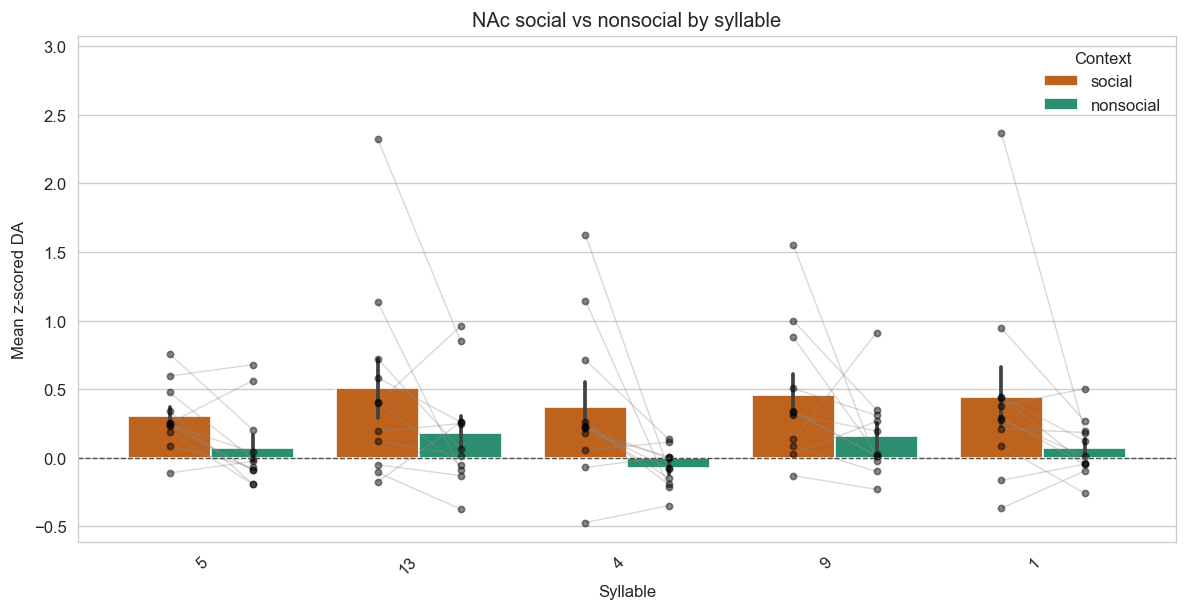

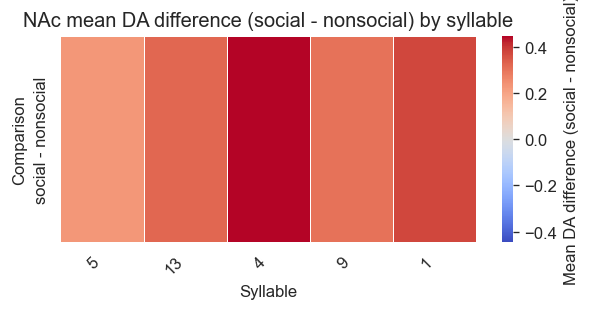

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

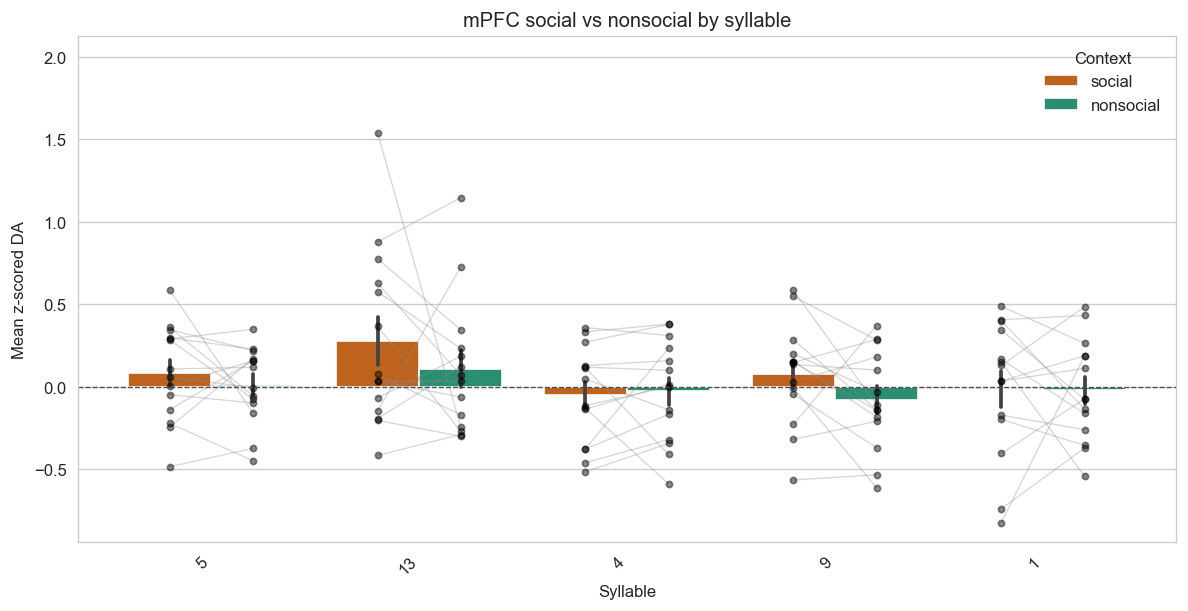

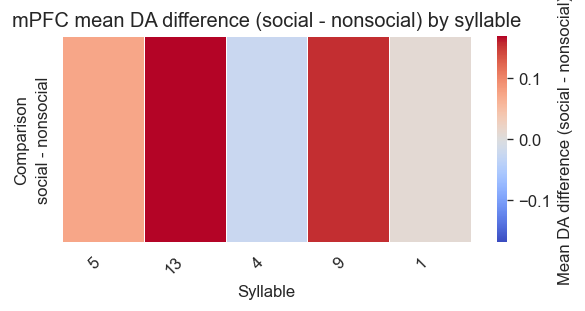

In [8]:

for region in REGION_ORDER:
    plot_social_context_barplot(
        subject_level_stats_df,
        social_context_stats_df,
        region=region,
        syllable_order=top_syllables,
    )
    plot_social_context_significance_heatmap(
        social_context_stats_df,
        region=region,
        syllable_order=top_syllables,
    )


In [9]:
bout_summary_df = summarize_mean_da_by_syllable_and_bout(
    merged_df,
    syllable_order=top_syllables,
    min_points_per_cell=MIN_POINTS_PER_CELL,
)

display(bout_summary_df.head(20))


,brain_region,bout_phase,social_context,syllable,n,mean_DA,median_DA,std_DA,n_subjects,sem_DA,meets_min_points
0,NAc,Long_Term-1,nonsocial,1,950,0.000277,-0.197091,1.112229,10,0.036085,True
1,NAc,Long_Term-1,nonsocial,4,1360,-0.183083,-0.338289,0.855689,9,0.023203,True
2,NAc,Long_Term-1,nonsocial,5,3878,0.064744,-0.150161,1.067661,10,0.017145,True
3,NAc,Long_Term-1,nonsocial,9,1589,0.335790,-0.000876,1.301290,8,0.032645,True
4,NAc,Long_Term-1,nonsocial,13,4877,0.084388,-0.082401,0.997513,8,0.014284,True
5,NAc,Long_Term-1,social,1,168,0.217448,-0.058225,1.180668,8,0.091091,True
6,NAc,Long_Term-1,social,4,408,0.016267,-0.162708,0.944844,8,0.046777,True
7,NAc,Long_Term-1,social,5,980,-0.052448,-0.233497,1.067811,8,0.034110,True
8,NAc,Long_Term-1,social,9,388,0.761659,0.047781,2.223074,7,0.112859,True
9,NAc,Long_Term-1,social,13,738,0.389212,0.061029,1.628155,8,0.059933,True


In [10]:

social_subject_level_stats_df = build_subject_level_syllable_da(
    merged_df[merged_df['social_context'].eq('social')].copy(),
    top_syllables,
)
social_agent_omnibus_stats_df, social_agent_pairwise_stats_df, _ = run_top_syllable_stats(
    social_subject_level_stats_df
)

# print('Social-only agent omnibus stats by syllable (Friedman)')
# display(social_agent_omnibus_stats_df)

print('Significant social-only agent omnibus tests (p < 0.05):')
display(social_agent_omnibus_stats_df.loc[social_agent_omnibus_stats_df['p_value'] < 0.05])

print('Social-only agent pairwise stats by syllable (Wilcoxon, FDR corrected)')
display(social_agent_pairwise_stats_df)

print('Significant social-only agent pairwise tests (p_val < 0.05):')
display(social_agent_pairwise_stats_df.loc[social_agent_pairwise_stats_df['p_value'] < 0.05])


print('Significant social-only agent pairwise tests (FDR < 0.05):')
display(social_agent_pairwise_stats_df.loc[social_agent_pairwise_stats_df['p_value_fdr_bh'] < 0.05])


Significant social-only agent omnibus tests (p < 0.05):


,brain_region,syllable,agent_levels,n_agents,n_subjects_complete,test,statistic,p_value,kendalls_w
4,NAc,13,Long_Term-1|Novel-1|Short_Term-1|Short_Term-2,4,5,Friedman,9.24,0.026264,0.616


Social-only agent pairwise stats by syllable (Wilcoxon, FDR corrected)


,brain_region,syllable,agent_a,agent_b,n_subjects_paired,test,statistic,p_value,mean_diff_a_minus_b,median_diff_a_minus_b,p_value_fdr_bh
0,NAc,1,Long_Term-1,Novel-1,8,Wilcoxon signed-rank,16.0,0.843750,-1.035136,-0.063916,0.910156
1,NAc,1,Long_Term-1,Short_Term-1,8,Wilcoxon signed-rank,11.0,0.382812,0.257057,0.237754,0.744141
2,NAc,1,Long_Term-1,Short_Term-2,6,Wilcoxon signed-rank,6.0,0.437500,-0.376138,-0.332873,0.744141
3,NAc,1,Novel-1,Short_Term-1,11,Wilcoxon signed-rank,21.0,0.320312,0.927014,0.278060,0.744141
4,NAc,1,Novel-1,Short_Term-2,9,Wilcoxon signed-rank,16.0,0.496094,1.035915,0.810502,0.744141
5,NAc,1,Short_Term-1,Short_Term-2,9,Wilcoxon signed-rank,21.0,0.910156,-0.132985,0.168262,0.910156
6,NAc,4,Long_Term-1,Novel-1,5,Wilcoxon signed-rank,7.0,1.000000,0.178905,-0.035348,1.000000
7,NAc,4,Long_Term-1,Short_Term-1,8,Wilcoxon signed-rank,10.0,0.312500,0.318679,0.155062,1.000000
8,NAc,4,Long_Term-1,Short_Term-2,6,Wilcoxon signed-rank,9.0,0.843750,0.104443,0.276346,1.000000
9,NAc,4,Novel-1,Short_Term-1,8,Wilcoxon signed-rank,17.0,0.945312,0.259114,0.014846,1.000000


Significant social-only agent pairwise tests (p_val < 0.05):


,brain_region,syllable,agent_a,agent_b,n_subjects_paired,test,statistic,p_value,mean_diff_a_minus_b,median_diff_a_minus_b,p_value_fdr_bh
19,NAc,9,Long_Term-1,Short_Term-1,7,Wilcoxon signed-rank,2.0,0.046875,1.239148,0.624826,0.281250
28,NAc,13,Novel-1,Short_Term-2,8,Wilcoxon signed-rank,0.0,0.007812,1.957543,0.574531,0.023438
29,NAc,13,Short_Term-1,Short_Term-2,8,Wilcoxon signed-rank,0.0,0.007812,0.562290,0.499694,0.023438
34,mPFC,1,Novel-1,Short_Term-2,8,Wilcoxon signed-rank,0.0,0.007812,0.958121,0.850942,0.046875


Significant social-only agent pairwise tests (FDR < 0.05):


,brain_region,syllable,agent_a,agent_b,n_subjects_paired,test,statistic,p_value,mean_diff_a_minus_b,median_diff_a_minus_b,p_value_fdr_bh
28,NAc,13,Novel-1,Short_Term-2,8,Wilcoxon signed-rank,0.0,0.007812,1.957543,0.574531,0.023438
29,NAc,13,Short_Term-1,Short_Term-2,8,Wilcoxon signed-rank,0.0,0.007812,0.562290,0.499694,0.023438
34,mPFC,1,Novel-1,Short_Term-2,8,Wilcoxon signed-rank,0.0,0.007812,0.958121,0.850942,0.046875


In [11]:

import pingouin as pg

def _find_balanced_agent_syllable_subset(
    group: pd.DataFrame,
    min_complete_subjects: int = 4,
) -> tuple[pd.DataFrame, list[str], list[int], list[str]]:
    work = group.dropna(subset=['subject_name', 'intruder_identity', 'syllable', 'mean_DA']).copy()
    if work.empty:
        return pd.DataFrame(), [], [], []

    work['intruder_identity'] = work['intruder_identity'].astype(str)
    work['syllable'] = work['syllable'].astype(int)

    agent_order = [agent for agent in BOUT_PHASE_ORDER if agent in set(work['intruder_identity'])]
    syllable_order = sorted(work['syllable'].unique().tolist())
    if len(agent_order) < 2 or len(syllable_order) < 2:
        return pd.DataFrame(), agent_order, syllable_order, []

    wide = work.pivot_table(
        index='subject_name',
        columns=['intruder_identity', 'syllable'],
        values='mean_DA',
        observed=True,
    )
    if isinstance(wide.columns, pd.MultiIndex):
        wide.columns = wide.columns.set_names(['intruder_identity', 'syllable'])

    candidate_syllables = [
        syllable for syllable in syllable_order
        if all((agent, syllable) in wide.columns for agent in agent_order)
    ]

    best_balanced = pd.DataFrame()
    best_syllables: list[int] = []
    best_subjects: list[str] = []

    while len(candidate_syllables) >= 2:
        cols = pd.MultiIndex.from_product([agent_order, candidate_syllables])
        current = wide.reindex(columns=cols)
        complete_subjects = current.dropna(axis=0).index.tolist()

        if len(complete_subjects) > len(best_subjects) or (
            len(complete_subjects) == len(best_subjects) and len(candidate_syllables) > len(best_syllables)
        ):
            if len(complete_subjects) >= 2:
                best_balanced = (
                    current.loc[complete_subjects]
                    .stack([0, 1])
                    .rename('mean_DA')
                    .reset_index()
                )
                best_balanced.columns = ['subject_name', 'intruder_identity', 'syllable', 'mean_DA']
                best_balanced['intruder_identity'] = pd.Categorical(
                    best_balanced['intruder_identity'],
                    categories=agent_order,
                    ordered=True,
                )
                best_balanced['syllable'] = pd.Categorical(
                    best_balanced['syllable'].astype(int),
                    categories=candidate_syllables,
                    ordered=True,
                )
                best_syllables = list(candidate_syllables)
                best_subjects = list(complete_subjects)

        if len(complete_subjects) >= min_complete_subjects:
            return best_balanced, agent_order, best_syllables, best_subjects

        missing_by_syllable = {
            syllable: current.xs(syllable, level=1, axis=1).isna().sum().sum()
            for syllable in candidate_syllables
        }
        drop_syllable = max(missing_by_syllable, key=missing_by_syllable.get)
        candidate_syllables = [syllable for syllable in candidate_syllables if syllable != drop_syllable]

    return best_balanced, agent_order, best_syllables, best_subjects

def run_agent_by_syllable_rm_anova(subject_level_df: pd.DataFrame, min_complete_subjects: int = 4) -> pd.DataFrame:
    social_only = subject_level_df[subject_level_df['social_context'].eq('social')].copy()

    rm_rows = []
    for brain_region, group in social_only.groupby('brain_region', observed=True):
        complete, agent_order, syllable_order, keep_subjects = _find_balanced_agent_syllable_subset(
            group,
            min_complete_subjects=min_complete_subjects,
        )

        if complete.empty or len(syllable_order) < 2 or len(agent_order) < 2:
            for source_name in ['intruder_identity', 'syllable', 'intruder_identity * syllable']:
                rm_rows.append(pd.DataFrame([{
                    'brain_region': brain_region,
                    'Source': source_name,
                    'ddof1': np.nan,
                    'ddof2': np.nan,
                    'F': np.nan,
                    'p_unc': np.nan,
                    'p_GG_corr': np.nan,
                    'ng2': np.nan,
                    'eps': np.nan,
                    'n_subjects_complete': int(len(keep_subjects)),
                    'n_syllables': int(len(syllable_order)),
                    'n_agents': int(len(agent_order)),
                    'syllables_used': ', '.join(map(str, syllable_order)),
                }]))
            continue

        aov = pg.rm_anova(
            data=complete,
            dv='mean_DA',
            within=['intruder_identity', 'syllable'],
            subject='subject_name',
            detailed=True,
        )
        aov['brain_region'] = brain_region
        aov['n_subjects_complete'] = int(len(keep_subjects))
        aov['n_syllables'] = int(len(syllable_order))
        aov['n_agents'] = int(len(agent_order))
        aov['syllables_used'] = ', '.join(map(str, syllable_order))
        rm_rows.append(aov)

    return pd.concat(rm_rows, ignore_index=True)

def select_rm_columns(df: pd.DataFrame) -> pd.DataFrame:
    preferred = [
        'brain_region', 'Source',
        'ddof1', 'ddof2', 'DF', 'F', 'p_unc', 'p_GG_corr', 'ng2', 'eps',
        'n_subjects_complete', 'n_syllables', 'n_agents', 'syllables_used'
    ]
    cols = [c for c in preferred if c in df.columns]
    return df.loc[:, cols]

agent_by_syllable_rm_anova_df = run_agent_by_syllable_rm_anova(subject_level_stats_df)

print('RM-ANOVA by region: intruder_identity x syllable (social only)')
display(select_rm_columns(agent_by_syllable_rm_anova_df))


RM-ANOVA by region: intruder_identity x syllable (social only)


C:\Users\alber\AppData\Local\Temp\ipykernel_21672\287709654.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack([0, 1])
C:\Users\alber\AppData\Local\Temp\ipykernel_21672\287709654.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack([0, 1])
C:\Users\alber\AppData\Local\Temp\ipykernel_21672\287709654.py:48: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warnin

,brain_region,Source,ddof1,ddof2,F,p_unc,p_GG_corr,ng2,eps,n_subjects_complete,n_syllables,n_agents,syllables_used
0,NAc,intruder_identity,3,6,1.547036,0.296638,0.339520,0.350549,0.334448,3,2,4,"1, 5"
1,NAc,syllable,1,2,4.047730,0.181894,0.181894,0.077245,1.000000,3,2,4,"1, 5"
2,NAc,intruder_identity * syllable,3,6,1.795938,0.247988,0.312025,0.102686,0.334606,3,2,4,"1, 5"
3,mPFC,intruder_identity,3,9,0.799501,0.524705,0.493240,0.144577,0.675024,4,3,4,"1, 5, 9"
4,mPFC,syllable,2,6,0.985067,0.426635,0.418751,0.016250,0.832912,4,3,4,"1, 5, 9"
5,mPFC,intruder_identity * syllable,6,18,1.330945,0.294295,0.334396,0.049674,0.233727,4,3,4,"1, 5, 9"


c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

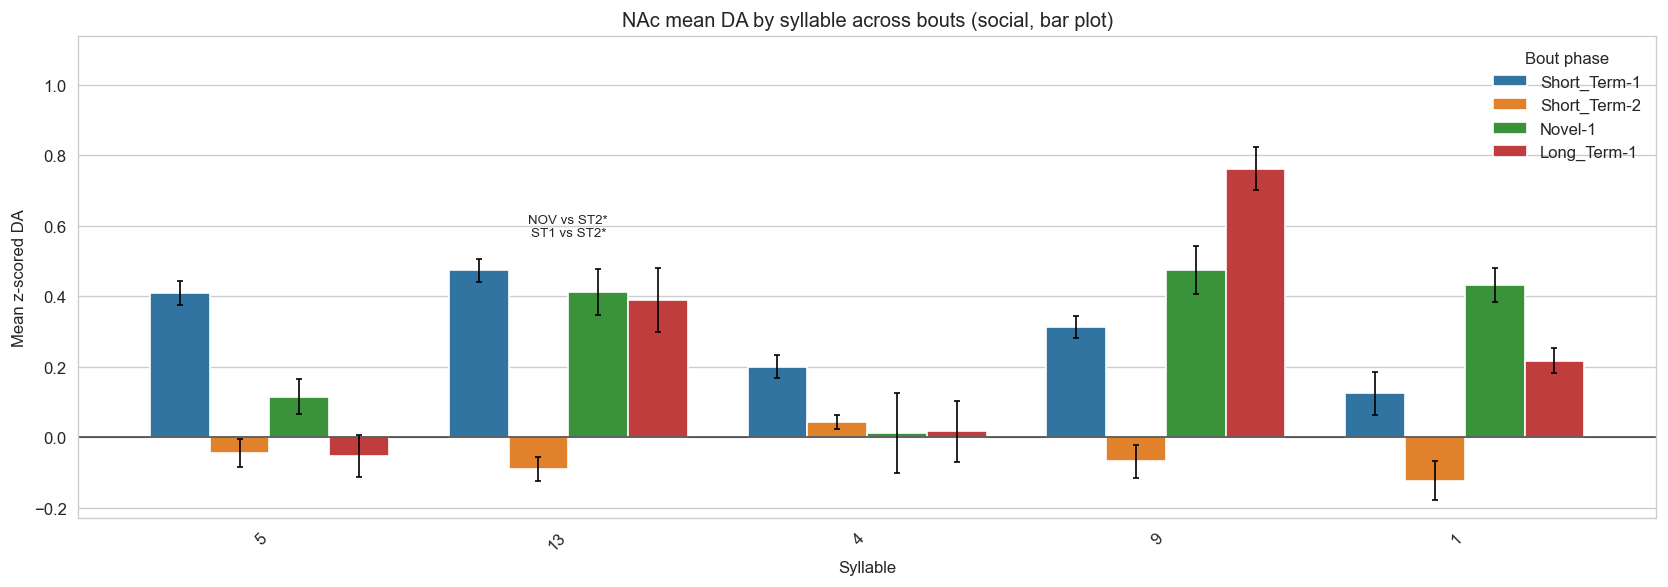

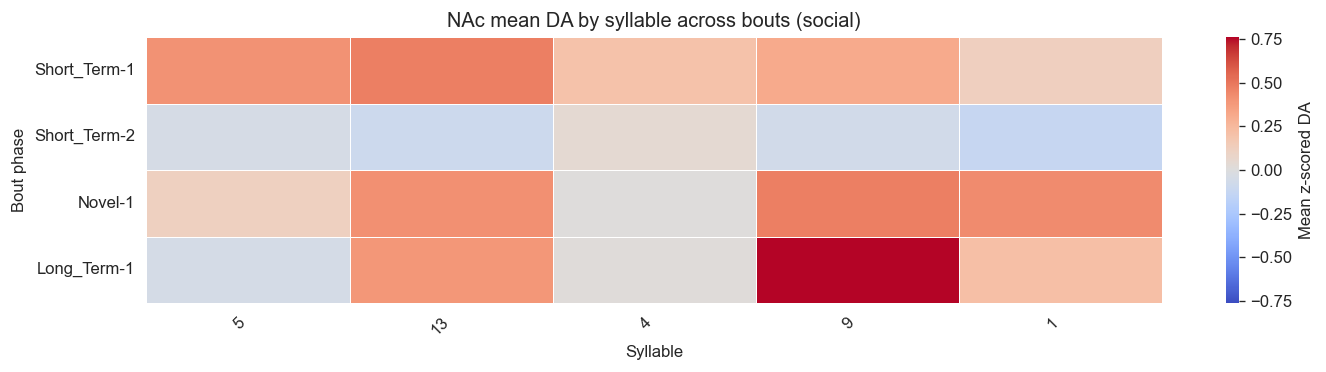

c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
c:\Users\alber\anaconda3\envs\keypoint_moseq\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of

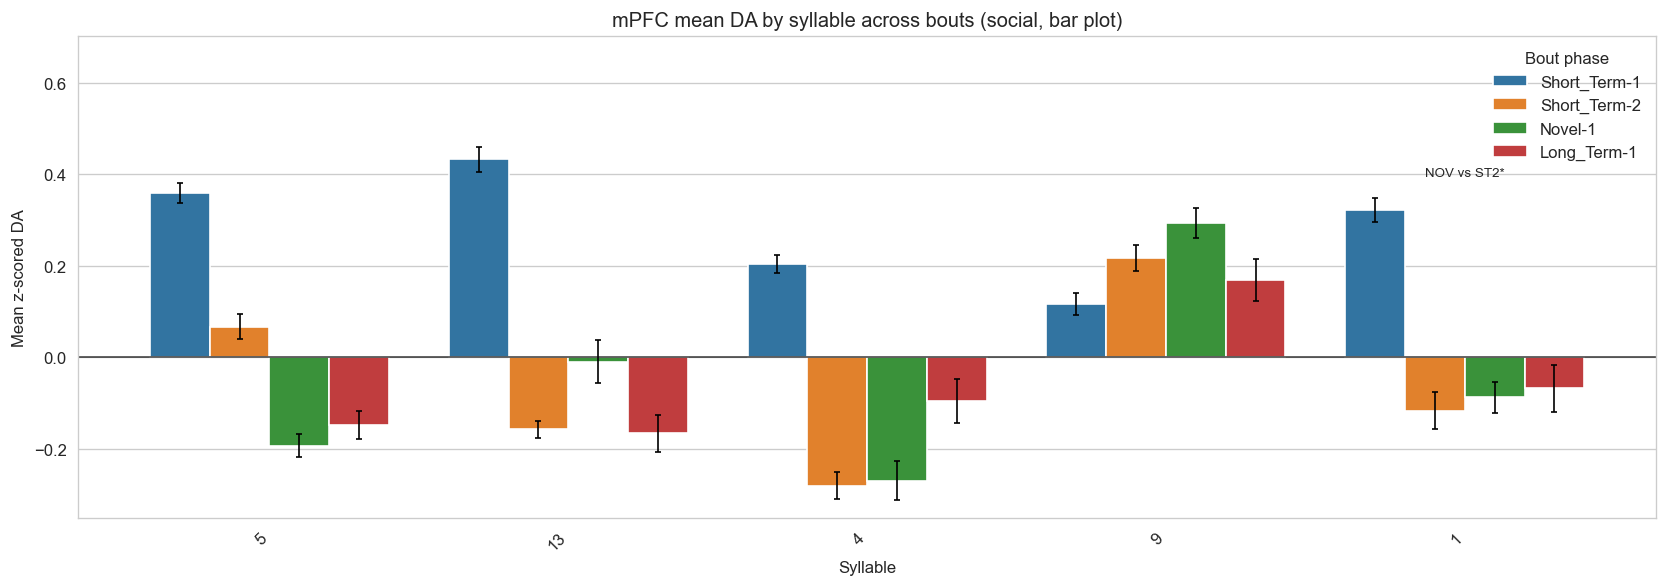

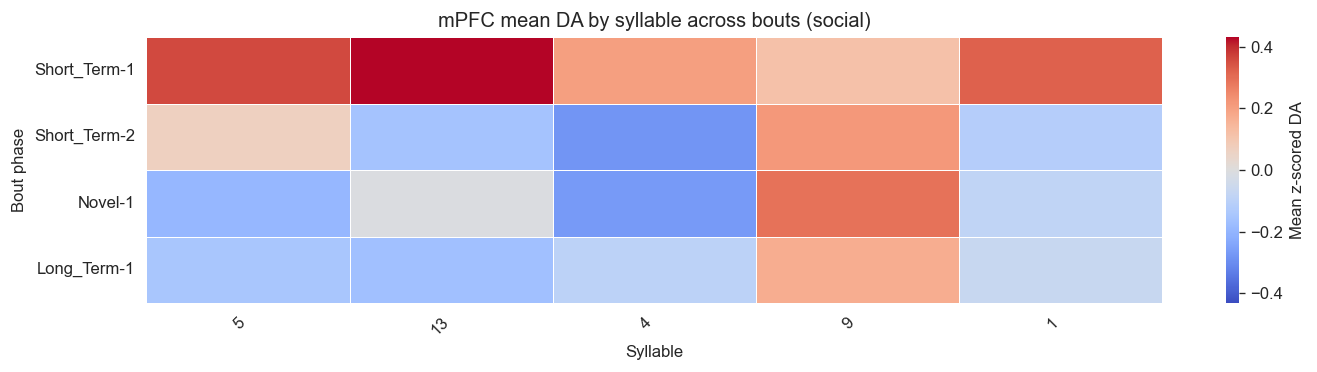

In [12]:

for region in REGION_ORDER:
    plot_region_agent_comparison_barplot(
        bout_summary_df,
        region=region,
        syllable_order=top_syllables,
        social_context='social',
        pairwise_stats_df=social_agent_pairwise_stats_df,
        output_path=None,
    )
    plot_region_agent_comparison_heatmap(
        bout_summary_df,
        region=region,
        syllable_order=top_syllables,
        social_context='social',
        output_path=None,
    )


In [13]:
heatmap_matrix = (
    summary_df.pivot_table(
        index=["brain_region", "social_context"],
        columns="syllable",
        values="mean_DA",
        observed=True,
    )
    .reset_index()
)
display(heatmap_matrix)


syllable,brain_region,social_context,1,4,5,9,13
0,NAc,nonsocial,0.011129,-0.099335,-0.021437,0.095862,0.024953
1,NAc,social,0.146045,0.100959,0.167421,0.395860,0.294391
2,mPFC,nonsocial,-0.152519,-0.089203,-0.047444,0.024802,-0.104681
3,mPFC,social,0.038416,-0.018626,0.098634,0.193054,0.057661


## Plot Heatmaps


In [14]:
print('Skipped older summary plot cell: use the social vs nonsocial bar plots and difference heatmaps above instead.')


Skipped older summary plot cell: use the social vs nonsocial bar plots and difference heatmaps above instead.


In [15]:
print('Skipped older agent-comparison plot cell: use the social vs nonsocial bar plots and difference heatmaps above instead.')


Skipped older agent-comparison plot cell: use the social vs nonsocial bar plots and difference heatmaps above instead.


## Summarize Syllable Onset Waveforms


In [16]:
syllable_aligned_df = annotate_syllable_frames_with_da(
    syllable_df,
    da_df,
    tolerance_s=TIME_TOLERANCE_S,
)
syllable_aligned_df = filter_bout_windows(syllable_aligned_df, SHORT_TERM_1_MAX_S)
syllable_aligned_df = exclude_syllables(syllable_aligned_df, SYLLABLES_TO_EXCLUDE)

onset_events_df = extract_syllable_onset_events(
    syllable_aligned_df,
    syllable_order=top_syllables,
)

aligned_onset_events_df, aligned_onset_long_df = build_syllable_onset_peth(
    onset_events_df,
    da_df,
    pre_s=PETH_PRE_S,
    post_s=PETH_POST_S,
    dt_s=PETH_DT_S,
)

onset_count_summary = summarize_onset_counts(aligned_onset_events_df)

display(aligned_onset_events_df.head())
display(onset_count_summary.head(20))
print(f"Aligned onset events: {len(aligned_onset_events_df)}")


C:\Users\alber\AppData\Local\Temp\ipykernel_21672\1286374452.py:152: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["social_proximity"] = merged["social_proximity"].fillna(False)
C:\Users\alber\AppData\Local\Temp\ipykernel_21672\1286374452.py:152: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged["social_proximity"] = merged["social_proximity"].fillna(False)
C:\Users\alber\AppData\Local\Temp\ipykernel_21672\1286374452.py:152: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

,event_id,recording_name,onset_frame_index,syllable,onset_time_s,subject_name,track_name,brain_region,zscore_DA,bout_phase,behavior_active,agent_in_subject,subject_in_agent,social_proximity,social_context,social_role,bout_elapsed_s,trace
0,67,n5_subject,1865,1,186.5,n5,subject,NAc,2.286924,Short_Term-1,Investigation,No,No,False,nonsocial,none,2.5,"[-0.4837053025150242, -0.6660920525959156, -0...."
1,68,n5_subject,1887,1,188.7,n5,subject,NAc,2.761061,Short_Term-1,Investigation,No,No,False,nonsocial,none,4.7,"[2.5787717884171104, 2.72906438254654, 2.31365..."
2,69,n5_subject,1890,5,189.0,n5,subject,NAc,2.192607,Short_Term-1,Investigation,No,No,False,nonsocial,none,5.0,"[2.568942223661192, 2.608677859163038, 1.97396..."
3,70,n5_subject,1973,13,197.3,n5,subject,NAc,2.549291,Short_Term-1,Investigation,No,No,False,nonsocial,none,13.3,"[4.173090765743721, 3.629949339185548, 3.09039..."
4,71,n5_subject,2103,5,210.3,n5,subject,NAc,4.127931,Short_Term-1,Investigation,No,Yes,True,social,subject_in_agent,26.3,"[5.9121571486834, 6.031728718128041, 6.0243700..."


,brain_region,social_context,social_role,syllable,n_events,n_subjects
0,NAc,nonsocial,none,1,763,11
1,NAc,nonsocial,none,4,424,11
2,NAc,nonsocial,none,5,780,11
3,NAc,nonsocial,none,9,300,11
4,NAc,nonsocial,none,13,353,11
5,NAc,social,agent_in_subject,1,45,11
6,NAc,social,agent_in_subject,4,24,9
7,NAc,social,agent_in_subject,5,52,11
8,NAc,social,agent_in_subject,9,18,6
9,NAc,social,agent_in_subject,13,24,10


Aligned onset events: 8294


In [17]:
if onset_count_summary.empty:
    onset_count_matrix = pd.DataFrame()
    print("No onset counts were available to pivot.")
else:
    onset_count_matrix = (
        onset_count_summary.pivot_table(
            index=["brain_region", "social_context", "social_role"],
            columns="syllable",
            values="n_events",
            observed=True,
        )
        .reset_index()
    )
    display(onset_count_matrix)


syllable,brain_region,social_context,social_role,1,4,5,9,13
0,NAc,nonsocial,none,763.0,424.0,780.0,300.0,353.0
1,NAc,social,agent_in_subject,45.0,24.0,52.0,18.0,24.0
2,NAc,social,both,86.0,53.0,101.0,43.0,42.0
3,NAc,social,subject_in_agent,42.0,24.0,58.0,27.0,10.0
4,mPFC,nonsocial,none,1257.0,590.0,1117.0,413.0,316.0
5,mPFC,social,agent_in_subject,117.0,73.0,119.0,46.0,17.0
6,mPFC,social,both,127.0,80.0,165.0,60.0,34.0
7,mPFC,social,subject_in_agent,170.0,77.0,152.0,63.0,32.0


## Plot Syllable Onset Waveforms


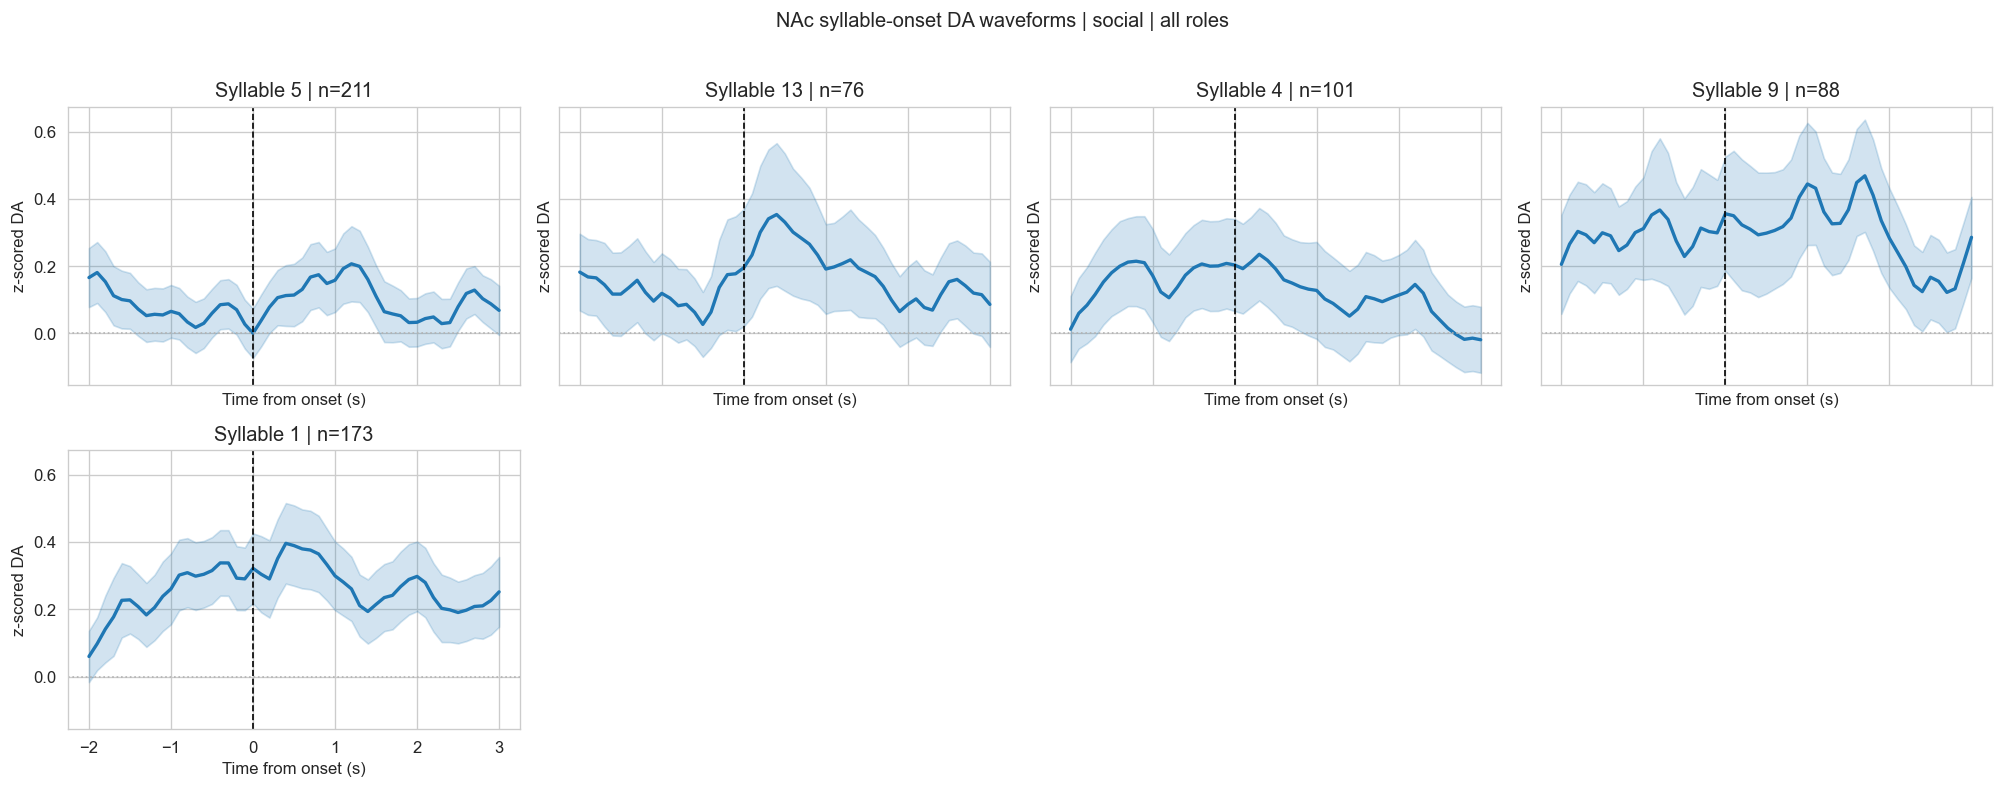

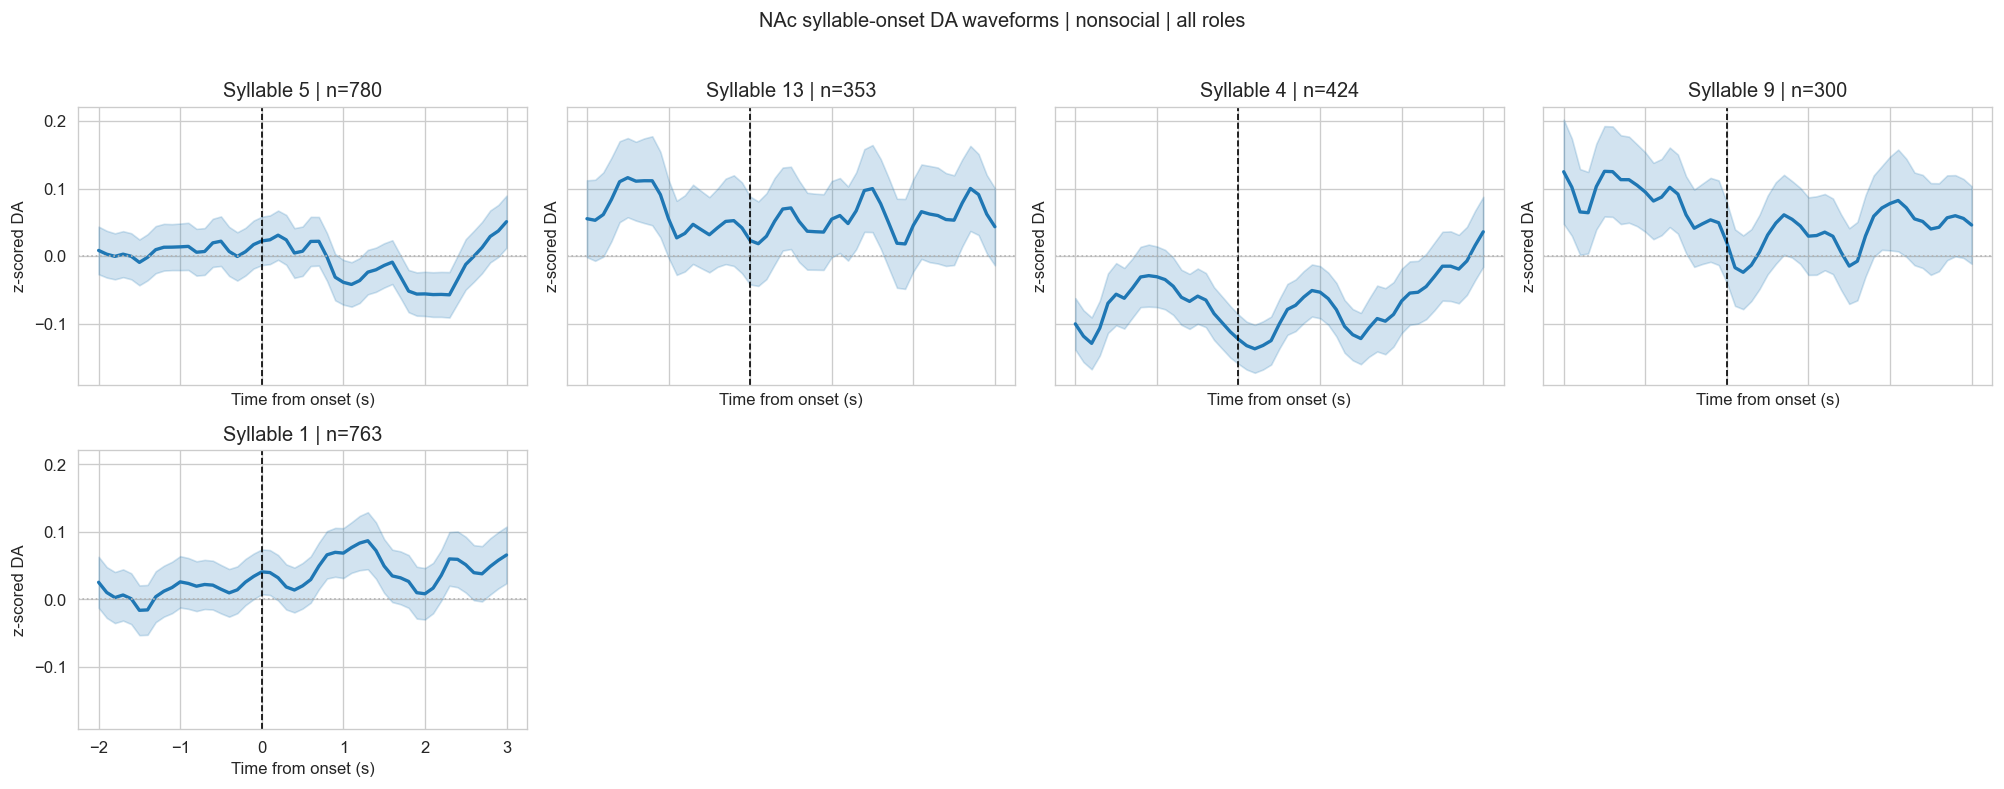

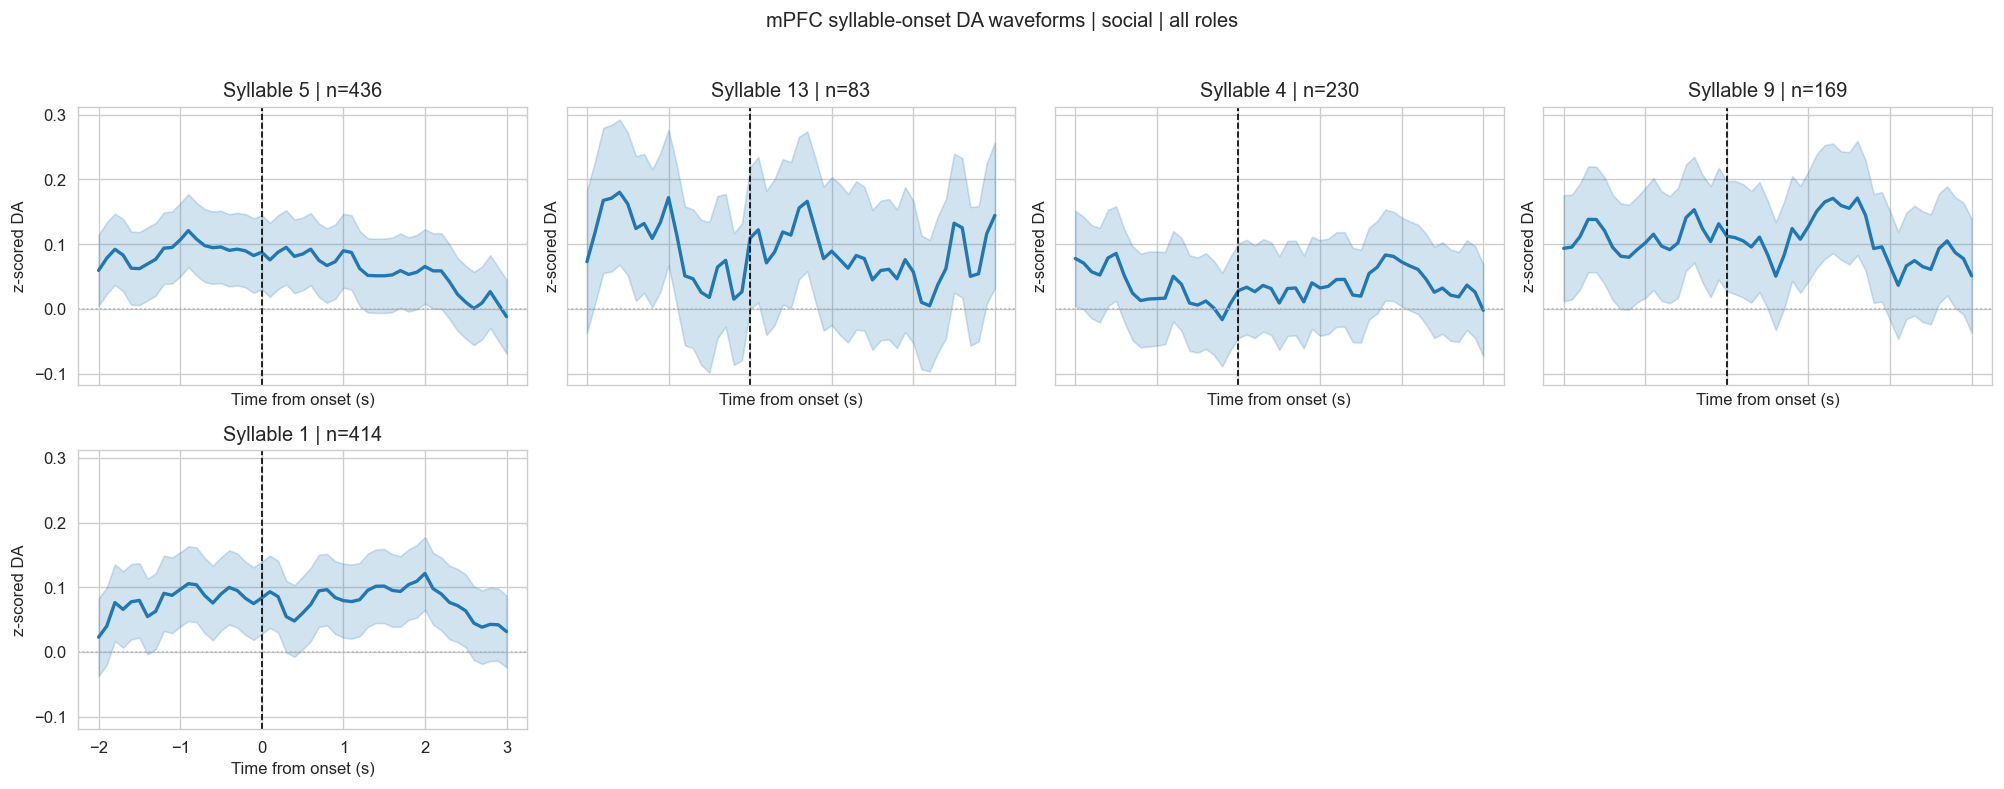

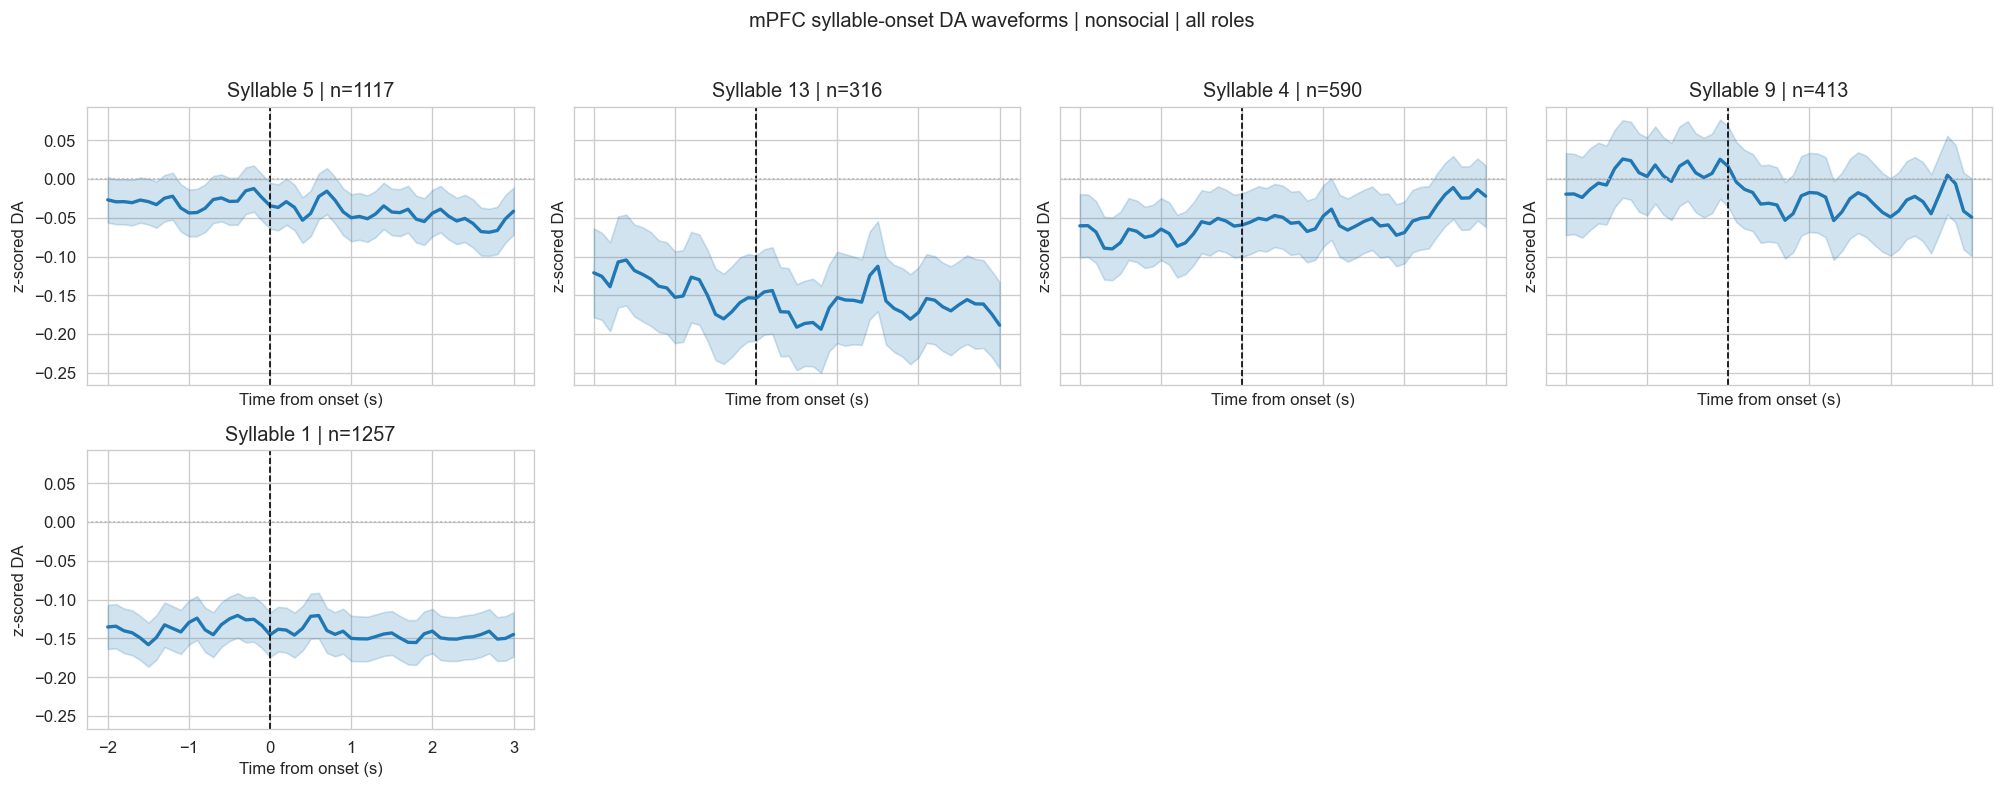

In [18]:
for region in REGION_ORDER:
    for social_context in SOCIAL_ORDER:
        plot_syllable_onset_peth_grid(
            aligned_onset_long_df,
            aligned_onset_events_df,
            region=region,
            syllable_order=top_syllables,
            social_context=social_context,
            social_role=None,
            min_events_per_syllable=MIN_EVENTS_PER_SYLLABLE,
            ncols=PETH_NCOLS,
        )


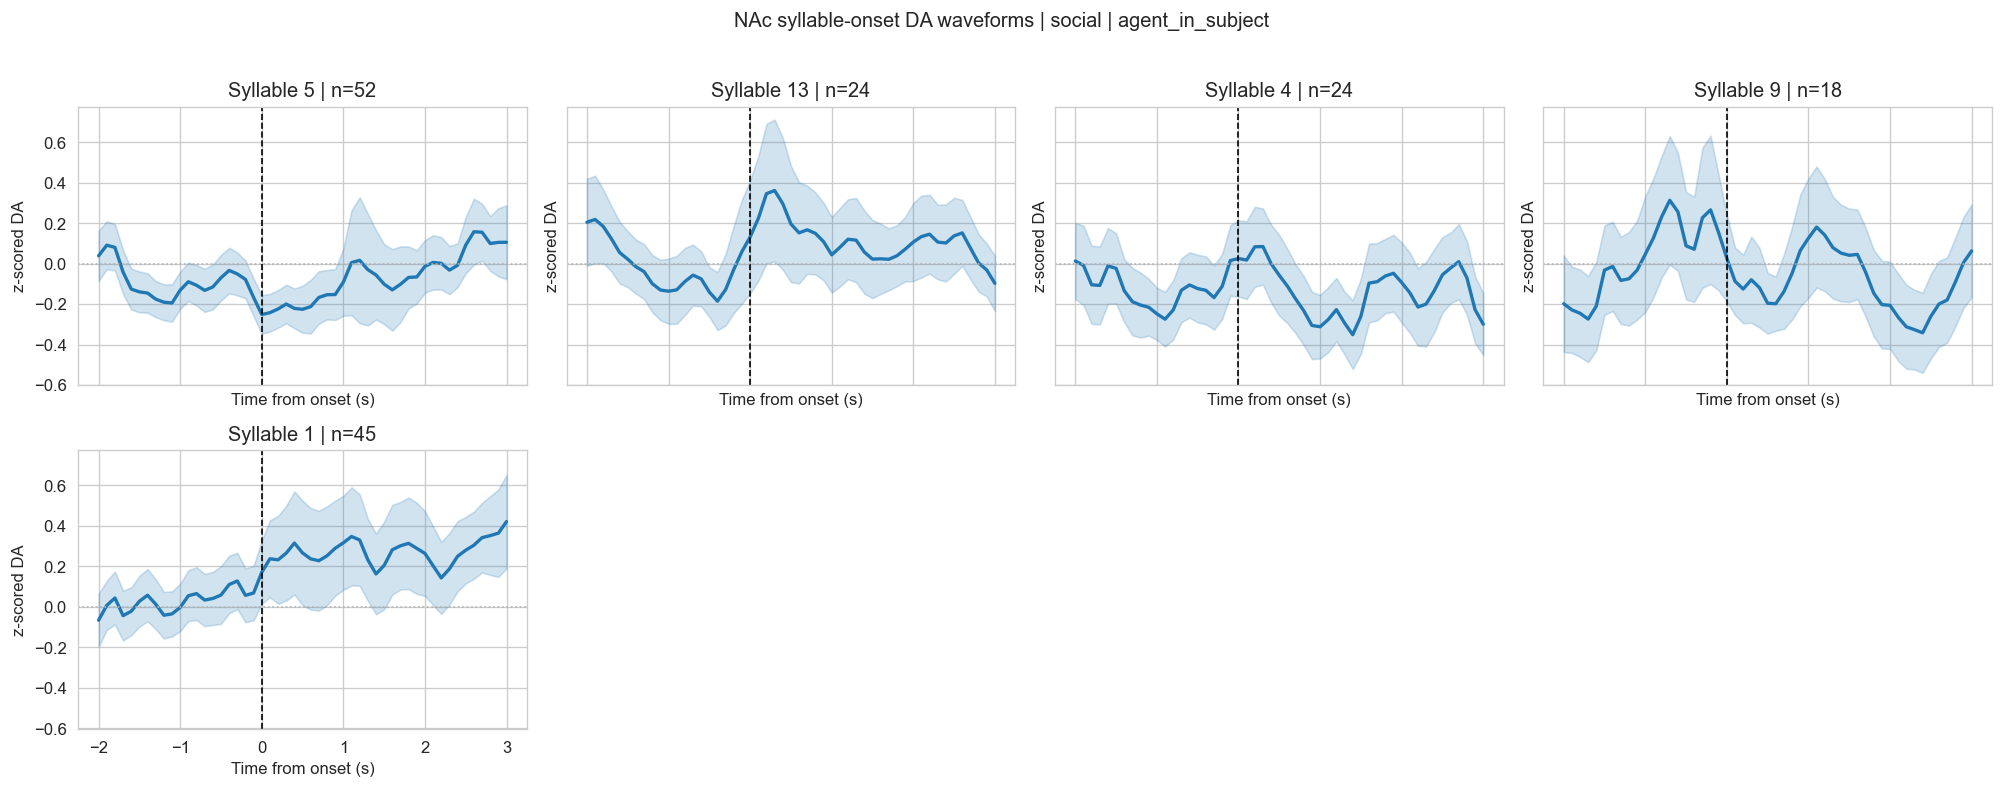

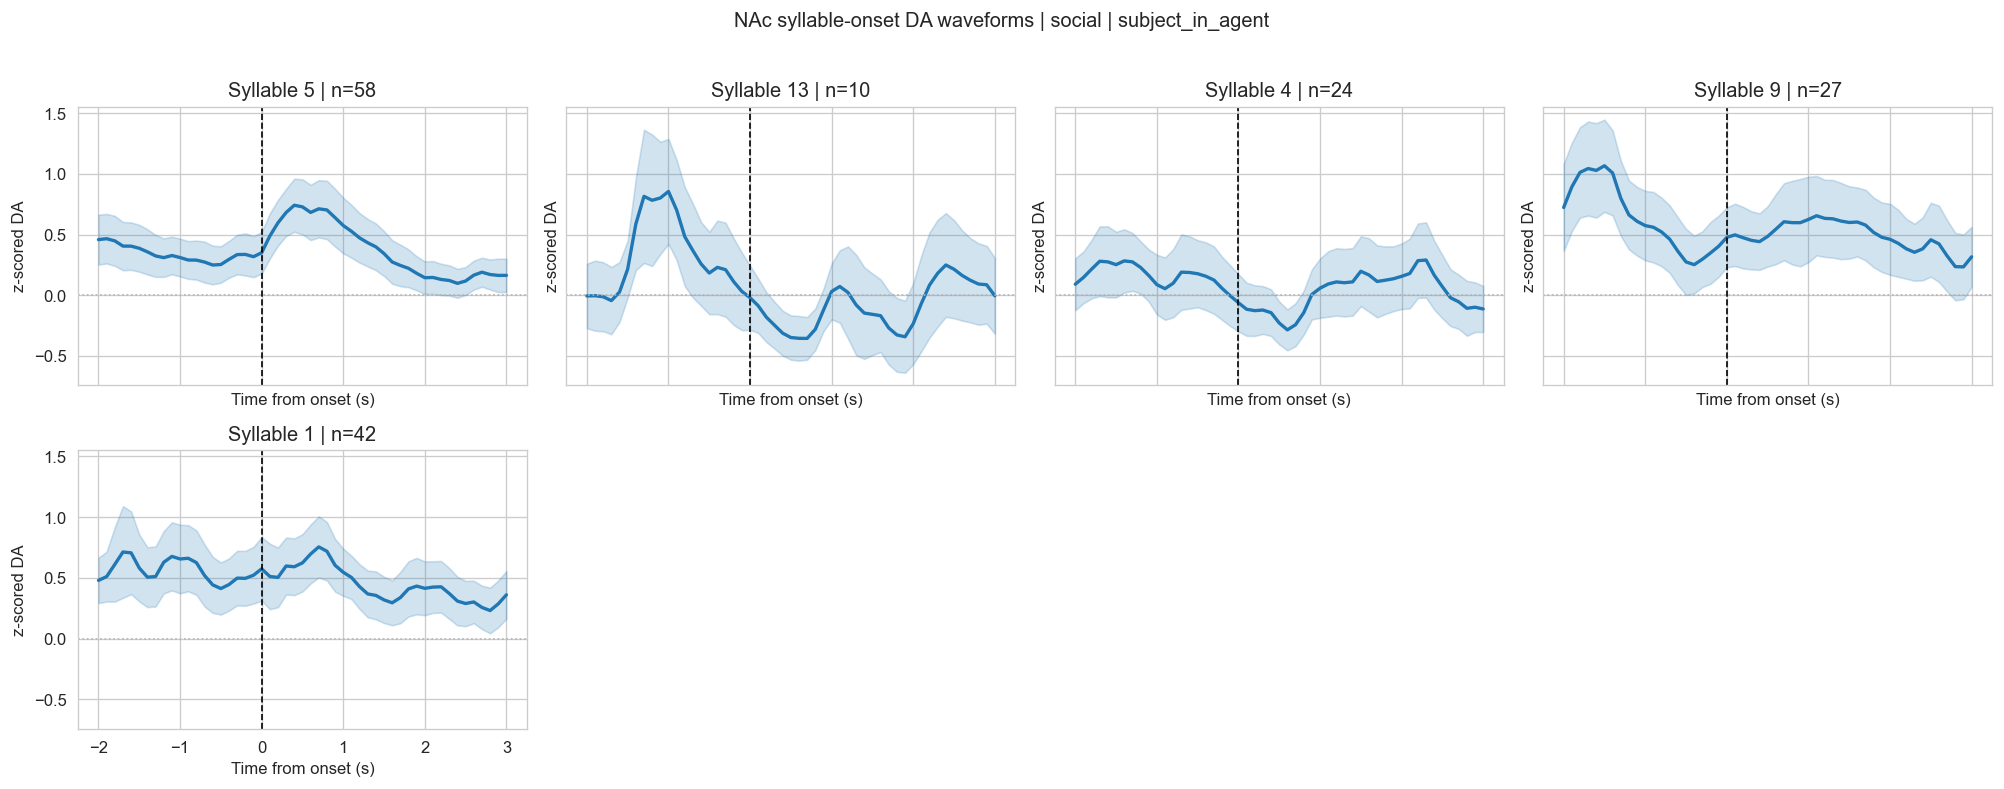

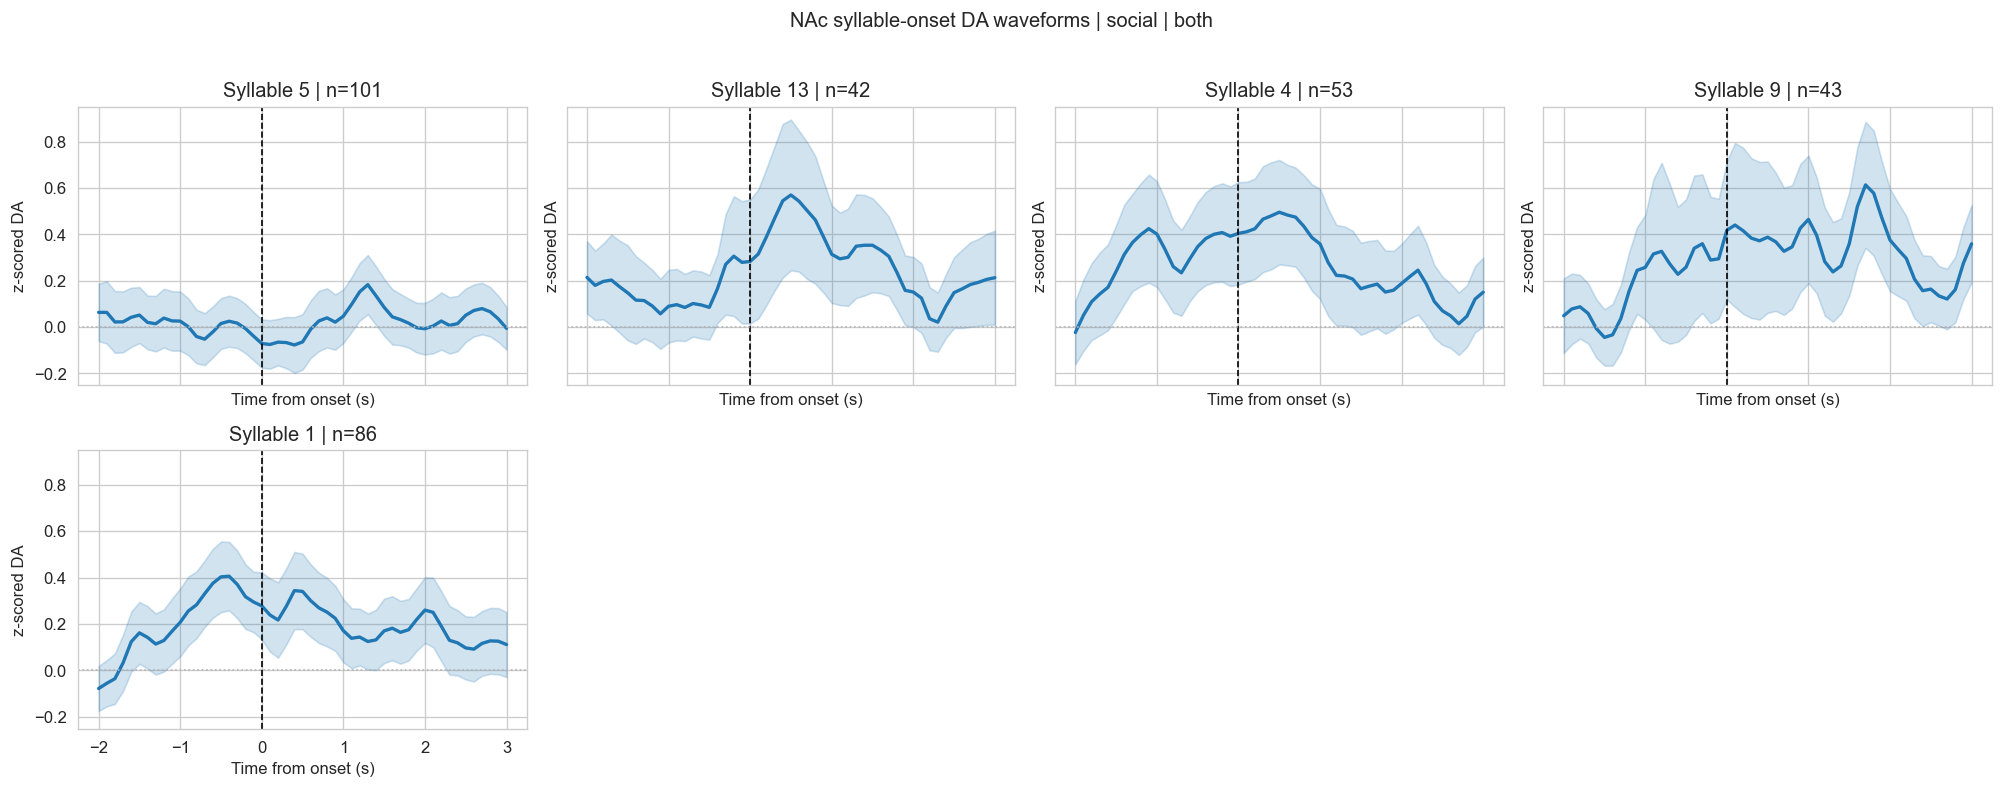

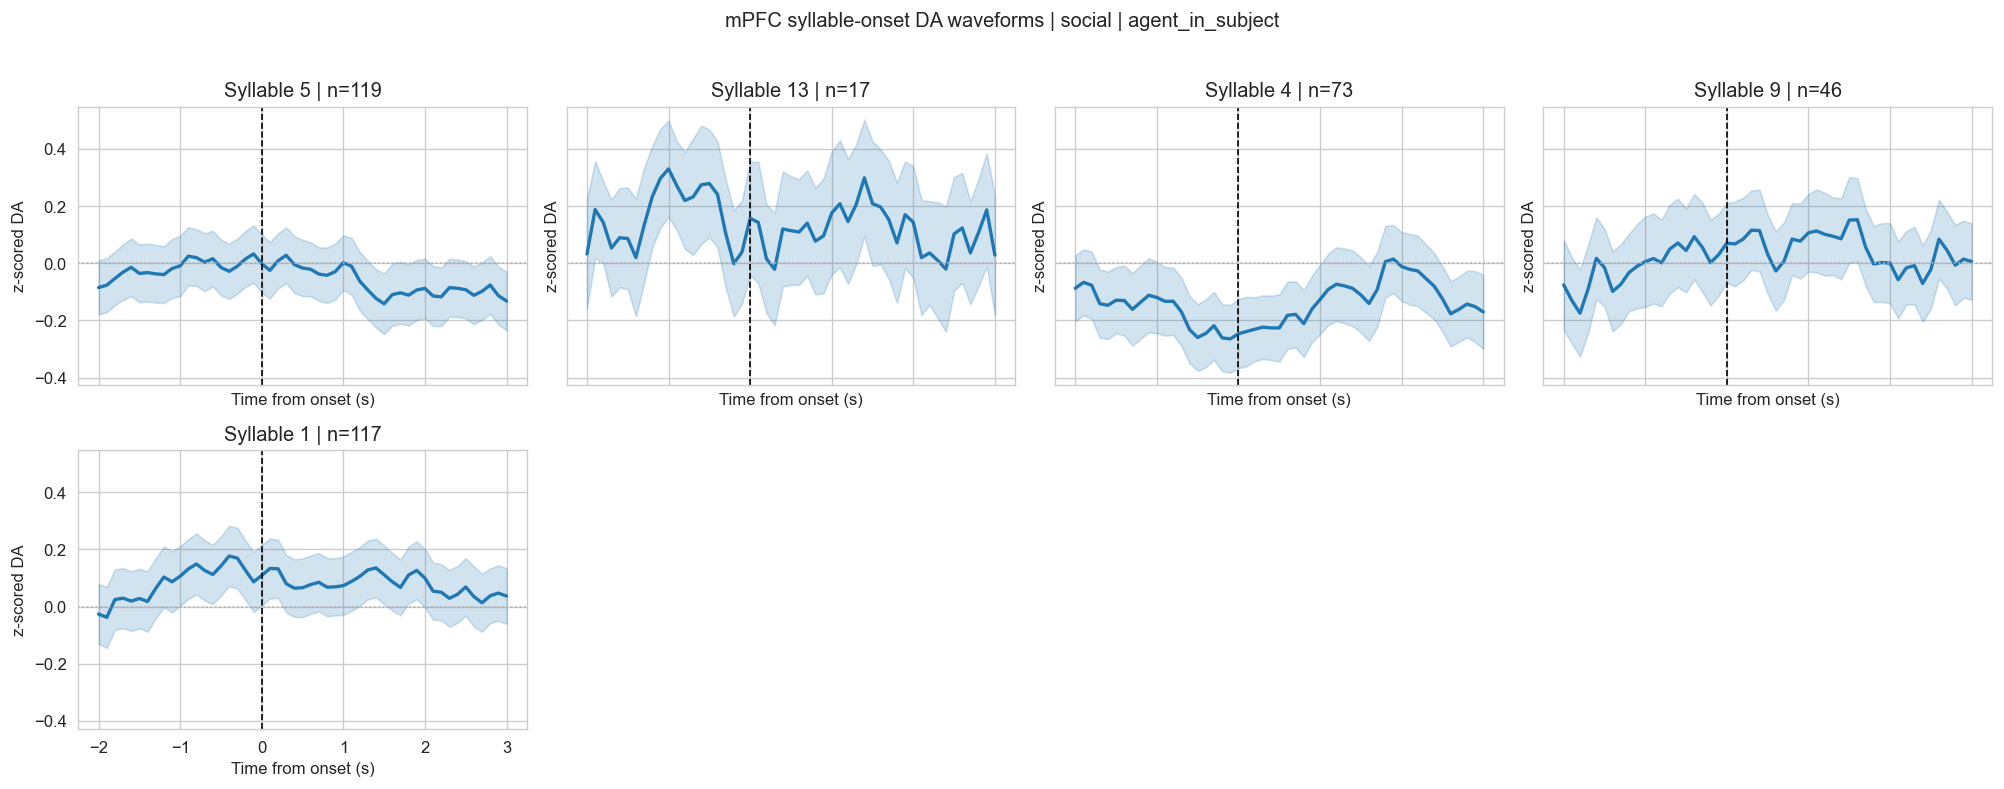

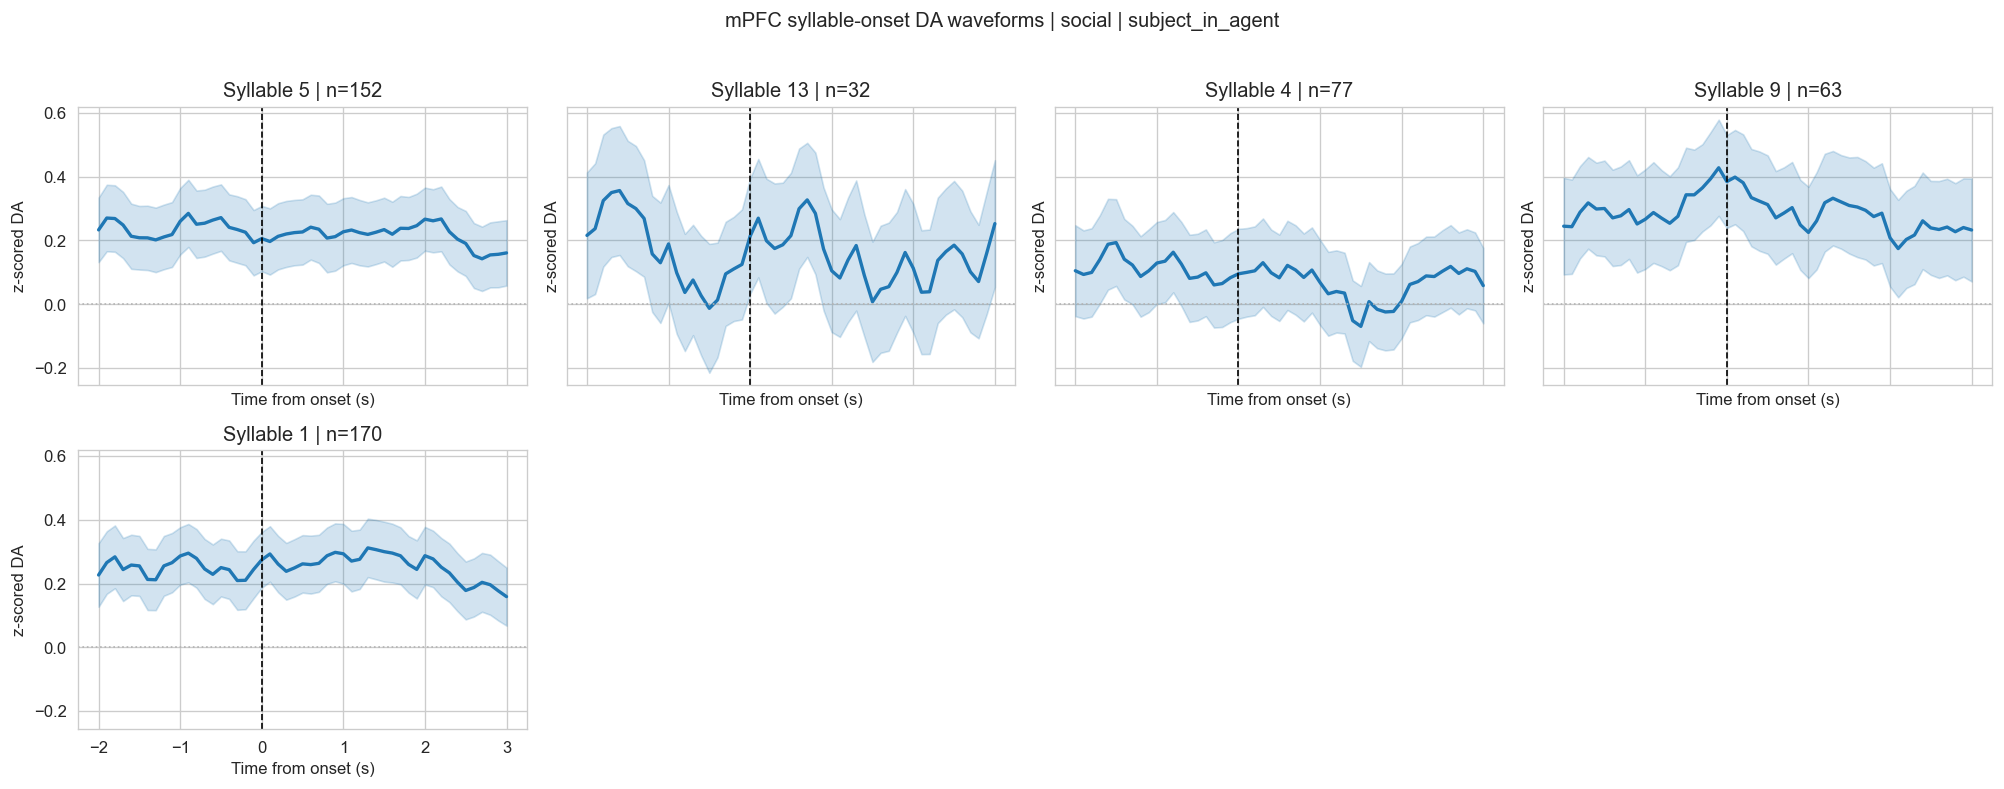

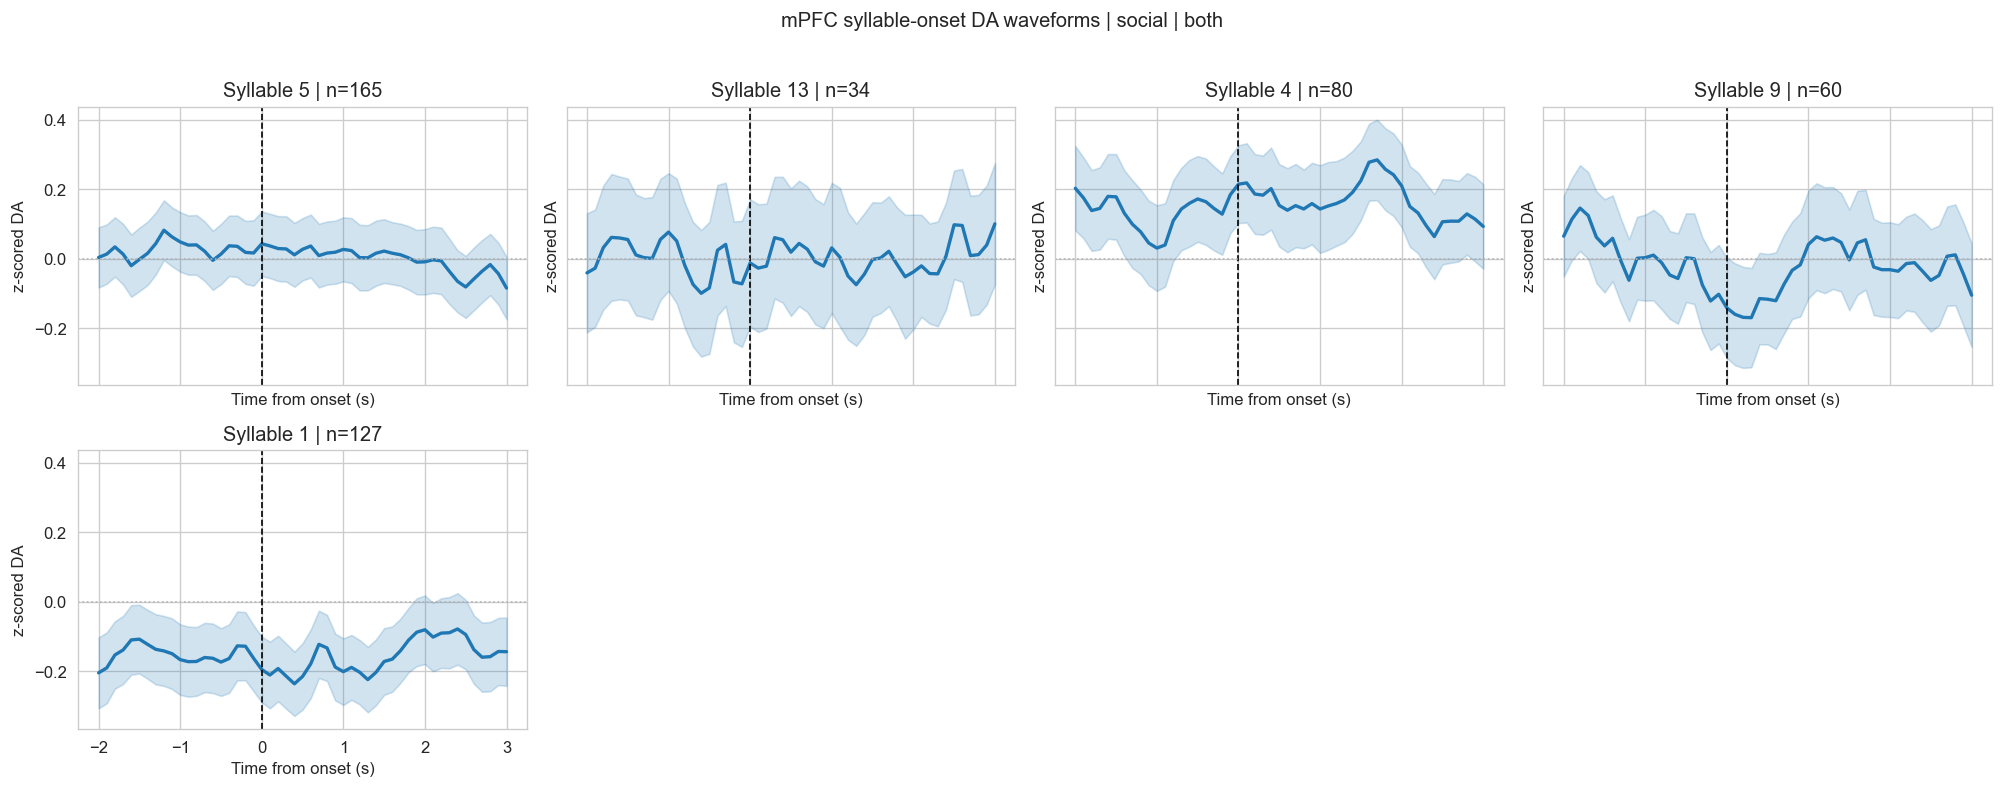

In [19]:
for region in REGION_ORDER:
    for social_role in SOCIAL_ROLE_ORDER:
        plot_syllable_onset_peth_grid(
            aligned_onset_long_df,
            aligned_onset_events_df,
            region=region,
            syllable_order=top_syllables,
            social_context="social",
            social_role=social_role,
            min_events_per_syllable=MIN_EVENTS_PER_SYLLABLE,
            ncols=PETH_NCOLS,
        )


## Save Outputs

In [20]:
# if SAVE_OUTPUTS:
#     merged_df.to_csv(OUTPUT_DIR / "da_with_syllables_social_context_long.csv", index=False)
#     summary_df.to_csv(OUTPUT_DIR / "syllable_mean_da_by_region_and_social_context.csv", index=False)
#     bout_summary_df.to_csv(OUTPUT_DIR / "syllable_mean_da_by_region_bout_and_social_context.csv", index=False)
#     heatmap_matrix.to_csv(OUTPUT_DIR / "syllable_mean_da_heatmap_matrix.csv", index=False)
#     syllable_aligned_df.to_csv(OUTPUT_DIR / "syllable_frames_with_da_context.csv", index=False)
#     onset_events_df.to_csv(OUTPUT_DIR / "syllable_onset_events.csv", index=False)
#     # aligned_onset_long_df.to_csv(OUTPUT_DIR / "syllable_onset_peth_long.csv", index=False)
#     onset_count_matrix.to_csv(OUTPUT_DIR / "syllable_onset_event_count_matrix.csv", index=False)
#     print(f"Wrote outputs to: {OUTPUT_DIR}")
# else:
#     print("SAVE_OUTPUTS is False, so no files were written.")
